# Hanks Lab — streaming a session from DANDI

Example file: session **119247**, subject **400**, from Dandiset
[001973](https://dandiarchive.org/dandiset/001973) (`sub-400/sub-400_ses-119247_image.nwb`, 1.84 GB).

This notebook streams the file from DANDI without downloading it, and covers everything in it:

- **Part A: acquisition.** Session metadata, the fiber photometry hardware, the raw ~6 kHz
  fiber photometry series and the behavior video.
- **Part B: processed signals.** The processed series, every stage of the lab's preprocessing
  pipeline, ΔF/F for all regions, and the artifact intervals.
- **Part C: behavior.** The Bpod task structure, events, states, actions and trials, and fiber
  photometry aligned to task events.

## What is in the file

### Raw fiber photometry (`acquisition`)

The NWB file contains dLight 3.8 dopamine signals acquired simultaneously from four brain
regions (NAc, DMS, DLS, PL/TS) acquired via a Doric FP Console. Each region is measured at two excitation wavelengths:
- **415/420 nm**: isosbestic control
- **490 nm**: dopamine signal

The file stores **two `FiberPhotometryResponseSeries`**, each with shape `(n_samples, 4)` at ~6024 Hz:

| Series name | Signal type            | Columns |
|---|------------------------|---|
| `FiberPhotometryResponseSeriesIsosbesticControl` | 415/420 nm isosbestic  | AIN01 → AIN02 → AIN03 → AIN04 |
| `FiberPhotometryResponseSeriesRawSignal` | 490 nm dopamine signal | AIN01 → AIN02 → AIN03 → AIN04 |

The per-session signal→brain-region mapping is stored in the `FiberPhotometryTable`
(`nwb.lab_meta_data["fiber_photometry"]`), together with the fibers, LEDs, photodetectors, filters
and indicator.

### Behavior video (`acquisition`)

A top-down video of the rat, stored as an `ImageSeries` named `BehaviorVideo`. The mp4 is **not
embedded** in the NWB file. It is a separate asset beside it in the dandiset, and the `ImageSeries`
holds its relative path (`external_file`) plus one timestamp per frame on the Doric clock.

### Processed fiber photometry (`processing/ophys`)

The output of the lab's preprocessing pipeline: **twelve `FiberPhotometryResponseSeries`**, each
`(n_samples, 4)` at ~200.8 Hz (the acquisition decimated 30×), with one column per region.
Isosbestic and signal versions are stored separately at each stage:

| Stage | Series | What it is |
|---|---|---|
| Decimated | `…DecimatedIsosbestic`, `…DecimatedSignal` | Raw signals decimated 30× |
| Filtered | `…FilteredIsosbestic`, `…FilteredSignal` | Low-pass filtered at 10 Hz |
| Isosbestic fit | `…FittedIsosbestic` | Linear fit of the isosbestic scaled to match the dopamine signal |
| Slow baseline | `…BaselineIsosbestic`, `…BaselineSignal` | Slow drift, low-pass filtered at ~0.0005 Hz |
| Baseline corrected | `…BaselineCorrectedIsosbestic`, `…BaselineCorrectedSignal` | Filtered signal minus its slow baseline |
| Frequency-band fit | `…FittedFreqBandBaselineIsosbestic` | Isosbestic fit per frequency band (0–0.5, 0.5–5, >5 Hz) |
| ΔF/F | `…DFF` | Isosbestic-corrected ΔF/F (`dff_iso`), the primary output |
| ΔF/F, alternative | `…DFFFreqBandCorrected` | ΔF/F from the frequency-band fit (`dff_iso_baseline_fband`) |

### Behavior (`acquisition` and `lab_meta_data`)

Behavior is recorded by a **Bpod** state machine and stored with `ndx-structured-behavior`, in two
parts:

| Where | Tables | What it holds |
|---|---|---|
| `nwb.lab_meta_data["task"]` | `EventTypesTable`, `StateTypesTable`, `ActionTypesTable` | The vocabulary: one row per port, state or output type |
| `nwb.acquisition["task_recording"]` | `EventsTable`, `StatesTable`, `ActionsTable` | Every occurrence: animal port pokes (events), state-machine states, machine outputs (actions) |

### Intervals (`intervals`)

| Table | One row per | What it holds |
|---|---|---|
| `trials` | Bpod trial | Start/stop times, outcomes (`hit`, `rewarded`, `choice`, …), task event times, and links to that trial's rows in the states, events and actions tables |
| `fiber_photometry_artifacts_intervals` | Unusable signal window | The region affected, the `artifact_type`, and references to the processed series it masks |

> **This dandiset is embargoed.** Streaming it needs a DANDI API token with access. Set it as
> `DANDI_API_KEY` in your environment before running. You can get one from your DANDI account page under
> *Profile → API key*. Once the dandiset is public, you can drop the token argument.

## Setup

In [1]:
# pip install pynwb dandi remfile nwb-video-widgets \
#     ndx-fiber-photometry ndx-ophys-devices ndx-structured-behavior networkx

import os

import h5py
import matplotlib.pyplot as plt
import ndx_fiber_photometry  # noqa: F401 — registers the extension
import ndx_ophys_devices  # noqa: F401
import ndx_structured_behavior  # noqa: F401
import networkx as nx
import numpy as np
import pandas as pd
import remfile
from dandi.dandiapi import DandiAPIClient
from matplotlib.patches import Patch
from ndx_fiber_photometry import FiberPhotometryResponseSeries
from ndx_structured_behavior.plot import (
    compute_state_transition_matrix,
    plot_actions,
    plot_events,
    plot_states,
    plot_trials,
)
from pynwb import NWBHDF5IO


### Streaming data from DANDI

Three layers, each wrapping the one before:

1. **`DandiAPIClient`** resolves the asset's path within the dandiset to a signed S3 URL. The API
   token is what authorizes that for an embargoed dandiset.
2. **`remfile`** turns that URL into a file-like object that serves HTTP range requests, so a read
   of bytes 1000–2000 fetches exactly those bytes.
3. **`h5py`** treats it as an HDF5 file, and `NWBHDF5IO` reads NWB on top.

In [2]:
DANDISET_ID = "001973"
ASSET_PATH = "sub-400/sub-400_ses-119247_image.nwb"

with DandiAPIClient(token=os.environ.get("DANDI_API_KEY")) as client:
    asset = client.get_dandiset(DANDISET_ID, "draft").get_asset_by_path(ASSET_PATH)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)

print(f"Asset    : {ASSET_PATH}")
print(f"Size     : {asset.size / 1e9:.2f} GB")

file = h5py.File(remfile.File(s3_url), "r")
io = NWBHDF5IO(file=file, mode="r", load_namespaces=True)
nwb = io.read()

print(f"Opened   : session {nwb.session_id}, subject {nwb.subject.subject_id}")

Asset    : sub-400/sub-400_ses-119247_image.nwb
Size     : 1.84 GB


Opened   : session 119247, subject 400


# Part A: acquisition

## 1. Session and subject metadata

In [3]:
print("Session ID     :", nwb.session_id)
print("Session start  :", nwb.session_start_time)
print("Lab            :", nwb.lab)
print("Institution    :", nwb.institution)
print("Experimenter   :", ", ".join(nwb.experimenter))
print()

subject = nwb.subject
print("Subject ID     :", subject.subject_id)
print("Species        :", subject.species)
print("Strain         :", subject.strain)
print("Sex            :", subject.sex)
print("Date of birth  :", subject.date_of_birth.date())
print("Weight         :", subject.weight)
print()
print("Description:")
print(nwb.session_description)

Session ID     : 119247
Session start  : 2025-10-02 11:48:47-07:00
Lab            : Hanks
Institution    : University of California, Davis
Experimenter   : Stevenson, Tanner

Subject ID     : 400
Species        : Rattus norvegicus
Strain         : Long Evans
Sex            : M
Date of birth  : 2024-03-19
Weight         : 530 g

Description:
This session contains fiber photometry and behavioral data from a rat performing an auditory working memory delay response task (ToneCatDelayResp). On each trial, a center port LED cue signals trial availability; the rat initiates by poking the center port and maintaining fixation, hears 1 auditory tone during a stimulus window, and after a delay period must poke the correct side port based on the remembered tone category to receive a water reward. Behavioral events are controlled and recorded by Bpod. Fluorescence signals are acquired simultaneously from up to four brain regions using a Doric system with dLight 3.8 (dopamine indicator) at isosbesti

### What is in the file

The overview at the top describes each data source. The cell below lists what is actually present in this file.

In [4]:
print("acquisition/")
for name, obj in sorted(nwb.acquisition.items()):
    shape = getattr(getattr(obj, "data", None), "shape", None)
    print(f"   {name:<50} {shape if shape else type(obj).__name__}")

print("\nprocessing/ophys/")
for name in sorted(nwb.processing["ophys"].data_interfaces):
    print(f"   {name}")

print("\nintervals/")
for name, table in nwb.intervals.items():
    print(f"   {name:<50} {len(table)} rows")

acquisition/
   BehaviorVideo                                      (0, 0, 0)
   FiberPhotometryResponseSeriesIsosbesticControl     (26653687, 4)
   FiberPhotometryResponseSeriesRawSignal             (26653687, 4)
   task_recording                                     TaskRecording

processing/ophys/
   FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic
   FiberPhotometryResponseSeriesBaselineCorrectedSignal
   FiberPhotometryResponseSeriesBaselineIsosbestic
   FiberPhotometryResponseSeriesBaselineSignal
   FiberPhotometryResponseSeriesDFF
   FiberPhotometryResponseSeriesDFFFreqBandCorrected
   FiberPhotometryResponseSeriesDecimatedIsosbestic
   FiberPhotometryResponseSeriesDecimatedSignal
   FiberPhotometryResponseSeriesFilteredIsosbestic
   FiberPhotometryResponseSeriesFilteredSignal
   FiberPhotometryResponseSeriesFittedFreqBandBaselineIsosbestic
   FiberPhotometryResponseSeriesFittedIsosbestic

intervals/
   fiber_photometry_artifacts_intervals               8 rows
   trials   

## 2. Fiber photometry hardware

The `FiberPhotometryTable` has one row per fiber per excitation wavelength, so four implanted
fibers give eight rows. Each response series points at its own four rows. Those rows tell you
**which column of the data array belongs to which brain region**.

In [5]:
fp_meta = nwb.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print("FiberPhotometryTable —", fp_table.description)
print()
fp_df = fp_table.to_dataframe()
# Simplify device columns to names only
for col in ["optical_fiber", "excitation_source", "photodetector", "indicator"]:
    if col in fp_df.columns:
        fp_df[col] = fp_df[col].apply(
            lambda x: x.name if hasattr(x, "name") else str(x)
        )
display_cols = ["location", "excitation_wavelength_in_nm", "emission_wavelength_in_nm",
                "optical_fiber", "excitation_source", "photodetector"]
fp_df[[c for c in display_cols if c in fp_df.columns]]

FiberPhotometryTable — Metadata for all fiber photometry recording sites and excitation wavelengths in this session.



,location,excitation_wavelength_in_nm,emission_wavelength_in_nm,optical_fiber,excitation_source,photodetector
id,,,,,,
0,Dorsolateral striatum,420.0,530.0,optical_fiber_DLS,excitation_source_isosbestic,PhotodetectorAIN01
1,Prelimbic area,420.0,530.0,optical_fiber_PL,excitation_source_isosbestic,PhotodetectorAIN02
2,Dorsomedial striatum,415.0,530.0,optical_fiber_DMS,excitation_source_isosbestic,PhotodetectorAIN03
3,Nucleus accumbens,415.0,530.0,optical_fiber_NAc,excitation_source_isosbestic,PhotodetectorAIN04
4,Dorsolateral striatum,490.0,530.0,optical_fiber_DLS,excitation_source_signal,PhotodetectorAIN01
5,Prelimbic area,490.0,530.0,optical_fiber_PL,excitation_source_signal,PhotodetectorAIN02
6,Dorsomedial striatum,490.0,530.0,optical_fiber_DMS,excitation_source_signal,PhotodetectorAIN03
7,Nucleus accumbens,490.0,530.0,optical_fiber_NAc,excitation_source_signal,PhotodetectorAIN04


In [6]:
print("Optical fibers and implant coordinates:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("optical_fiber_"):
        continue
    ins = getattr(dev, "fiber_insertion", None)
    if ins is not None:
        ap   = getattr(ins, "insertion_position_ap_in_mm", "?")
        ml   = getattr(ins, "insertion_position_ml_in_mm", "?")
        dv   = getattr(ins, "insertion_position_dv_in_mm", "?")
        hemi = getattr(ins, "hemisphere", "?")
        print(f"  {name}: AP={ap:+.2f}, ML={ml:+.2f}, DV={dv:.2f} mm  [{hemi}]")
    else:
        print(f"  {name}: no insertion coordinates")

print()
print("Excitation sources:")
for name in ("excitation_source_isosbestic", "excitation_source_signal"):
    dev = nwb.devices.get(name)
    if dev is None:
        continue
    desc = getattr(dev, "description", None) or ""
    model = getattr(dev, "model", None)
    wl_range = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"  [{wl_range[0]:.1f}–{wl_range[-1]:.1f} nm]" if wl_range is not None else ""
    print(f"  {name}: {desc[:80].rstrip()}{wl_str}")

print()
print("Photodetectors:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("Photodetector"):
        continue
    model = getattr(dev, "model", None)
    det_type  = getattr(model, "detector_type", "?")
    gain      = getattr(model, "gain", "?")
    gain_unit = getattr(model, "gain_unit", "")
    wl_range  = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"{wl_range[0]:.0f}–{wl_range[-1]:.0f} nm" if wl_range is not None else "?"
    print(f"  {name}: type={det_type}, gain={gain} {gain_unit}, sensitivity={wl_str}")

print()
print("Band optical filters:")
for name, dev in sorted(nwb.devices.items()):
    if not (name.startswith("emission_filter") or name.startswith("excitation_filter")):
        continue
    model  = getattr(dev, "model", None)
    center = getattr(model, "center_wavelength_in_nm", "?")
    bw     = getattr(model, "bandwidth_in_nm", "?")
    ftype  = getattr(model, "filter_type", "?")
    print(f"  {name}: {ftype}, center={center} nm, BW={bw} nm")

print()
print("Indicator:")
for ind in fp_meta.fiber_photometry_indicators.indicators.values():
    print(f"  {ind.name} — label: {ind.label}, manufacturer: {ind.manufacturer}")

Optical fibers and implant coordinates:
  optical_fiber_DLS: AP=+0.60, ML=+3.80, DV=-3.80 mm  [left]
  optical_fiber_DMS: AP=+1.10, ML=-2.10, DV=-3.60 mm  [right]
  optical_fiber_NAc: AP=+1.60, ML=+1.60, DV=-7.20 mm  [left]
  optical_fiber_PL: AP=+3.00, ML=-0.60, DV=-3.00 mm  [right]

Excitation sources:
  excitation_source_isosbestic: Doric LED driver channel delivering the isosbestic excitation wavelength (415/42  [408.5–421.5 nm]
  excitation_source_signal: Doric LED driver channel delivering the 490 nm excitation for dLight3.8.  [477.0–503.0 nm]

Photodetectors:
  PhotodetectorAIN01: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN02: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN03: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN04: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm

Band optical filters:
  emission_filter: Bandpass, center=525.0 nm, BW=50.0 nm
  excitation_filter_isosbestic_DLS: Bandpass, center=427.5 nm, 

## 3. The raw response series

There are two series, split by excitation wavelength: the **isosbestic control** (415/420 nm,
insensitive to dopamine binding) and the **signal** (490 nm, dLight3.8). Each is `(n_samples, 4)`.

In [7]:
iso_series = nwb.acquisition["FiberPhotometryResponseSeriesIsosbesticControl"]
sig_series = nwb.acquisition["FiberPhotometryResponseSeriesRawSignal"]


def column_regions(series):
    # Which brain region each column of `series` holds, from its own table region.
    rows = list(series.fiber_photometry_table_region.data[:])
    return [fp_df.iloc[i]["location"] for i in rows]


def region_column(series, location):
    # Column index of `location` within `series`.
    return column_regions(series).index(location)


regions = column_regions(sig_series)

SIGNAL_COLOR = {
    "Nucleus accumbens": "#9C27B0",
    "Dorsolateral striatum": "#2196F3",
    "Dorsomedial striatum": "#4CAF50",
    "Prelimbic area": "#FF5722",
    "Tail of striatum": "#FF9800",
}

for series in (iso_series, sig_series):
    timestamps = series.get_timestamps()
    print(f"{series.name}")
    print(f"   shape    : {series.data.shape}   unit={series.unit}")
    print(f"   duration : {timestamps[-1] - timestamps[0]:.1f} s, t0={timestamps[0]:.4f} s")
    print(f"   columns  : {column_regions(series)}")
    print()

FiberPhotometryResponseSeriesIsosbesticControl
   shape    : (26653687, 4)   unit=a.u.


   duration : 4424.5 s, t0=0.0831 s
   columns  : ['Dorsolateral striatum', 'Prelimbic area', 'Dorsomedial striatum', 'Nucleus accumbens']

FiberPhotometryResponseSeriesRawSignal
   shape    : (26653687, 4)   unit=a.u.


   duration : 4424.5 s, t0=0.0831 s
   columns  : ['Dorsolateral striatum', 'Prelimbic area', 'Dorsomedial striatum', 'Nucleus accumbens']



### One minute of the raw series

The raw 490 nm signal and isosbestic control for the nucleus accumbens, at the full ~6 kHz
acquisition rate with no downsampling. The two panels share both axes, so their levels compare
directly. Change `REGION` to plot another region.

The whole session is ~700 MB of compressed data per series, several minutes to stream, so this
plots one minute. Change `START_S` to look at another part of the session. Only the chunks
covering that minute are fetched.

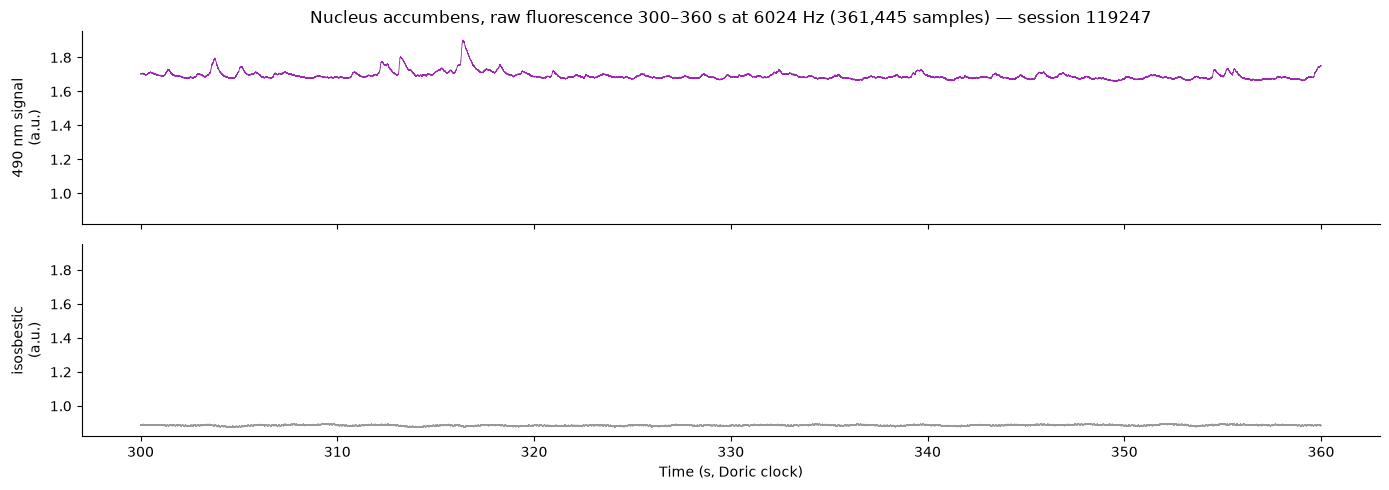

In [8]:
REGION = "Nucleus accumbens"
START_S, DURATION_S = 300.0, 60.0

# The raw series stores ~26 M explicit timestamps. Take the rate and first timestamp from the
# start and convert the window to sample indices, rather than streaming every timestamp.
raw_t0 = float(sig_series.timestamps[0])
raw_rate = 1 / np.median(np.diff(sig_series.timestamps[:1000]))
i0 = int((START_S - raw_t0) * raw_rate)
i1 = i0 + int(DURATION_S * raw_rate)

# One contiguous read per series — the cheap access pattern over HTTP
sig_window = sig_series.data[i0:i1, region_column(sig_series, REGION)]
iso_window = iso_series.data[i0:i1, region_column(iso_series, REGION)]
t_window = sig_series.timestamps[i0:i1]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True, sharey=True)
axes[0].plot(t_window, sig_window, color=SIGNAL_COLOR.get(REGION, "steelblue"), lw=0.6,
             rasterized=True)
axes[0].set_ylabel(f"490 nm signal\n({sig_series.unit})")
axes[1].plot(t_window, iso_window, color="#999999", lw=0.6, rasterized=True)
axes[1].set_ylabel(f"isosbestic\n({iso_series.unit})")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
axes[-1].set_xlabel("Time (s, Doric clock)")
axes[0].set_title(
    f"{REGION}, raw fluorescence {START_S:.0f}–{START_S + DURATION_S:.0f} s at {raw_rate:.0f} Hz "
    f"({i1 - i0:,} samples) — session {nwb.session_id}", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Whole session: the decimated series

The decimated signals (30× down from the ~6 kHz Doric clock) are the starting point of the
processing pipeline. Grey is the isosbestic control and color is the 490 nm signal.


888,457 samples, 0.09–4424.60 s


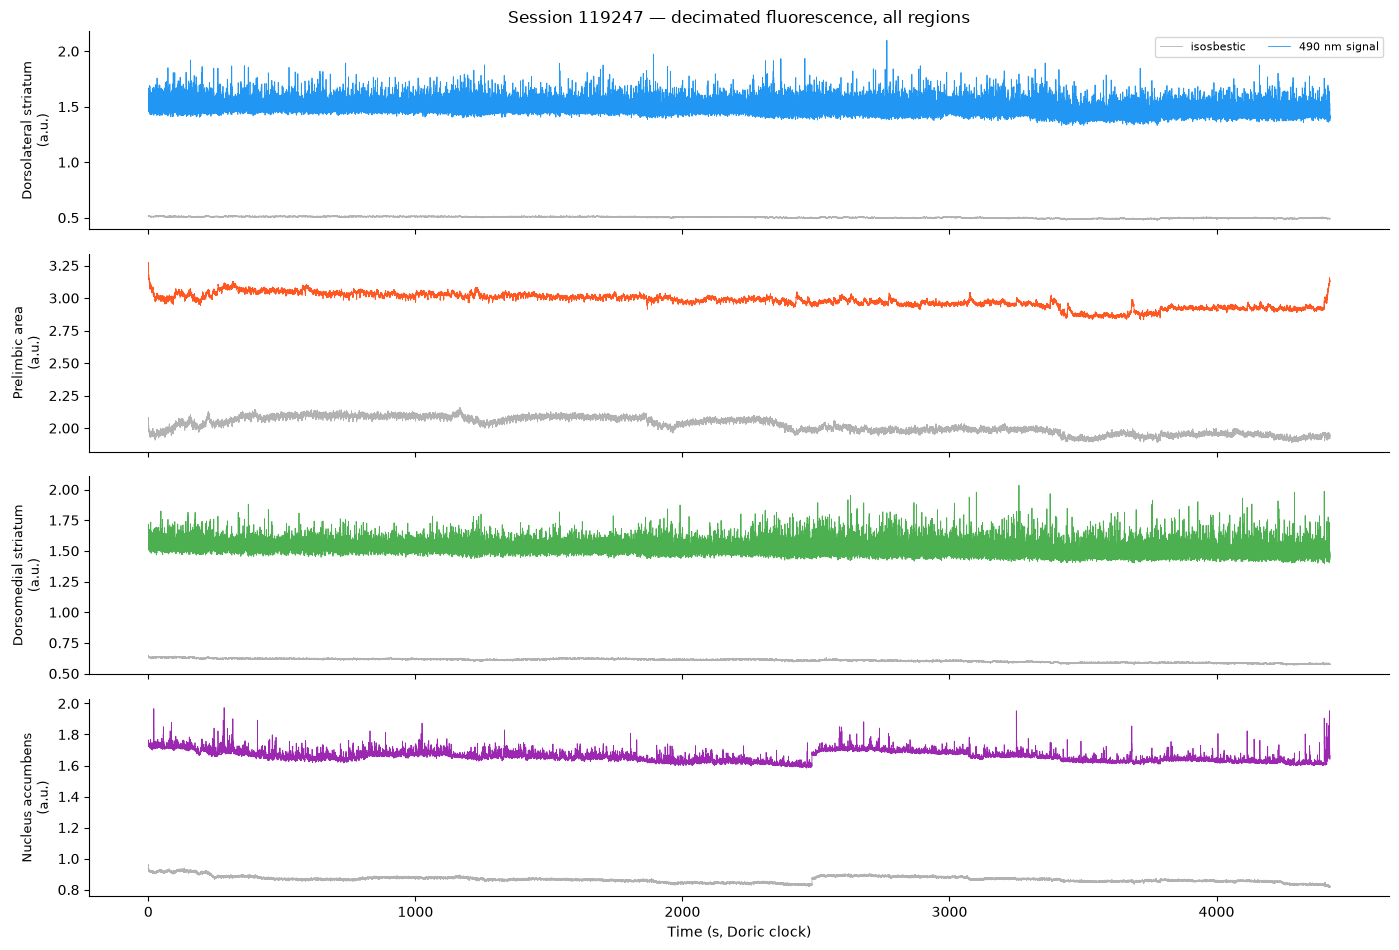

In [9]:
dec_iso = nwb.processing["ophys"]["FiberPhotometryResponseSeriesDecimatedIsosbestic"]
dec_sig = nwb.processing["ophys"]["FiberPhotometryResponseSeriesDecimatedSignal"]
dec_regions = column_regions(dec_sig)

# All processed series share the same sampling, so one time base serves them all.
ts = nwb.processing["ophys"]["FiberPhotometryResponseSeriesDFF"].get_timestamps()
print(f"{len(ts):,} samples, {ts[0]:.2f}–{ts[-1]:.2f} s")

fig, axes = plt.subplots(len(dec_regions), 1, figsize=(14, 2.4 * len(dec_regions)), sharex=True)
for ax, region in zip(np.atleast_1d(axes), dec_regions):
    ax.plot(ts, dec_iso.data[:, region_column(dec_iso, region)],
            color="#999999", lw=0.6, alpha=0.75, label="isosbestic", rasterized=True)
    ax.plot(ts, dec_sig.data[:, region_column(dec_sig, region)],
            color=SIGNAL_COLOR.get(region, "steelblue"), lw=0.6, label="490 nm signal",
            rasterized=True)
    ax.set_ylabel(f"{region}\n({dec_sig.unit})", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

np.atleast_1d(axes)[0].legend(loc="upper right", fontsize=8, ncol=2)
np.atleast_1d(axes)[-1].set_xlabel("Time (s, Doric clock)")
np.atleast_1d(axes)[0].set_title(
    f"Session {nwb.session_id} — decimated fluorescence, all regions", fontsize=12)
fig.tight_layout()
plt.show()

## 5. Behavior video

The video is **not stored inside the NWB file**. The `ImageSeries` holds an `external_file` path
and the frame timestamps. The mp4 sits beside the NWB as a separate asset in the dandiset, which
keeps the NWB small and lets the video stream on its own.

`nwb_video_widgets` resolves that path against the dandiset and plays the video from S3. The frame
timestamps are on the same Doric clock, so a position in this player is directly comparable with a
time in the plots above.

In [10]:
video = nwb.acquisition["BehaviorVideo"]
frame_times = np.asarray(video.timestamps[:])

print("External file :", video.external_file[:][0])
print(f"Frames        : {len(frame_times):,}")
print(f"Duration      : {frame_times[-1] - frame_times[0]:.2f} s")
print()
print("Camera        :", video.device.name, "/", video.device.model.model_number)

External file : sub-400_ses-119247_image/1e95750f-55c9-4678-9d69-7f61947bb396_external_file_0.mp4
Frames        : 132,865
Duration      : 4424.64 s

Camera        : BehaviorCamera / DMK 33UX290


In [11]:
from nwb_video_widgets import get_dandi_video_info

# Resolves each external_file path to the S3 URL of its companion asset
info = get_dandi_video_info(asset=asset)
for name, entry in info.items():
    print(f"{name}: {entry['start']:.2f}–{entry['end']:.2f} s")
    print(f"   {entry['url'][:96]}...")

BehaviorVideo: 0.00–4424.64 s
   https://dandiarchive.s3.amazonaws.com/blobs/4d3/596/4d35965b-d447-4aa0-8598-ede620758640?respons...


In [12]:
from nwb_video_widgets import NWBDANDIVideoPlayer

NWBDANDIVideoPlayer(asset=asset)

# Part B: processed signals

The lab's preprocessing pipeline output is stored under `processing/ophys` as twelve
`FiberPhotometryResponseSeries`. All twelve share one layout: the ~6 kHz acquisition decimated 30×
to ~200 Hz, with one column per region.

## 6. The processed series

In [13]:
ophys = nwb.processing["ophys"]
proc_series = {
    name: obj
    for name, obj in ophys.data_interfaces.items()
    if isinstance(obj, FiberPhotometryResponseSeries)
}

print(f"{len(proc_series)} FiberPhotometryResponseSeries in processing['ophys']:\n")
for name, s in proc_series.items():
    n_samples, n_cols = s.data.shape
    if s.rate is not None:
        timing = f"rate={s.rate:.2f} Hz, t0={s.starting_time:.4f} s"
    else:
        ts = s.timestamps
        rate_est = (len(ts) - 1) / (float(ts[-1]) - float(ts[0]))
        timing = f"~{rate_est:.2f} Hz (from timestamps), t0={float(ts[0]):.4f} s"
    print(f"  {name}")
    print(f"    shape=({n_samples}, {n_cols}), {timing}, unit={s.unit}")

12 FiberPhotometryResponseSeries in processing['ophys']:

  FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineCorrectedSignal
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineIsosbestic
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineSignal
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDFF
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDFFFreqBandCorrected
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDecimatedIsosbestic
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDecimatedSignal
    shape=(888457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesFilteredIsosbestic
 

## 7. Processing pipeline walkthrough: one region

The cell below shows every processed series for a single region, in pipeline order. Change
`REGION` to any of the regions above. The isosbestic and signal series can order their columns
differently, so each has its own column index.


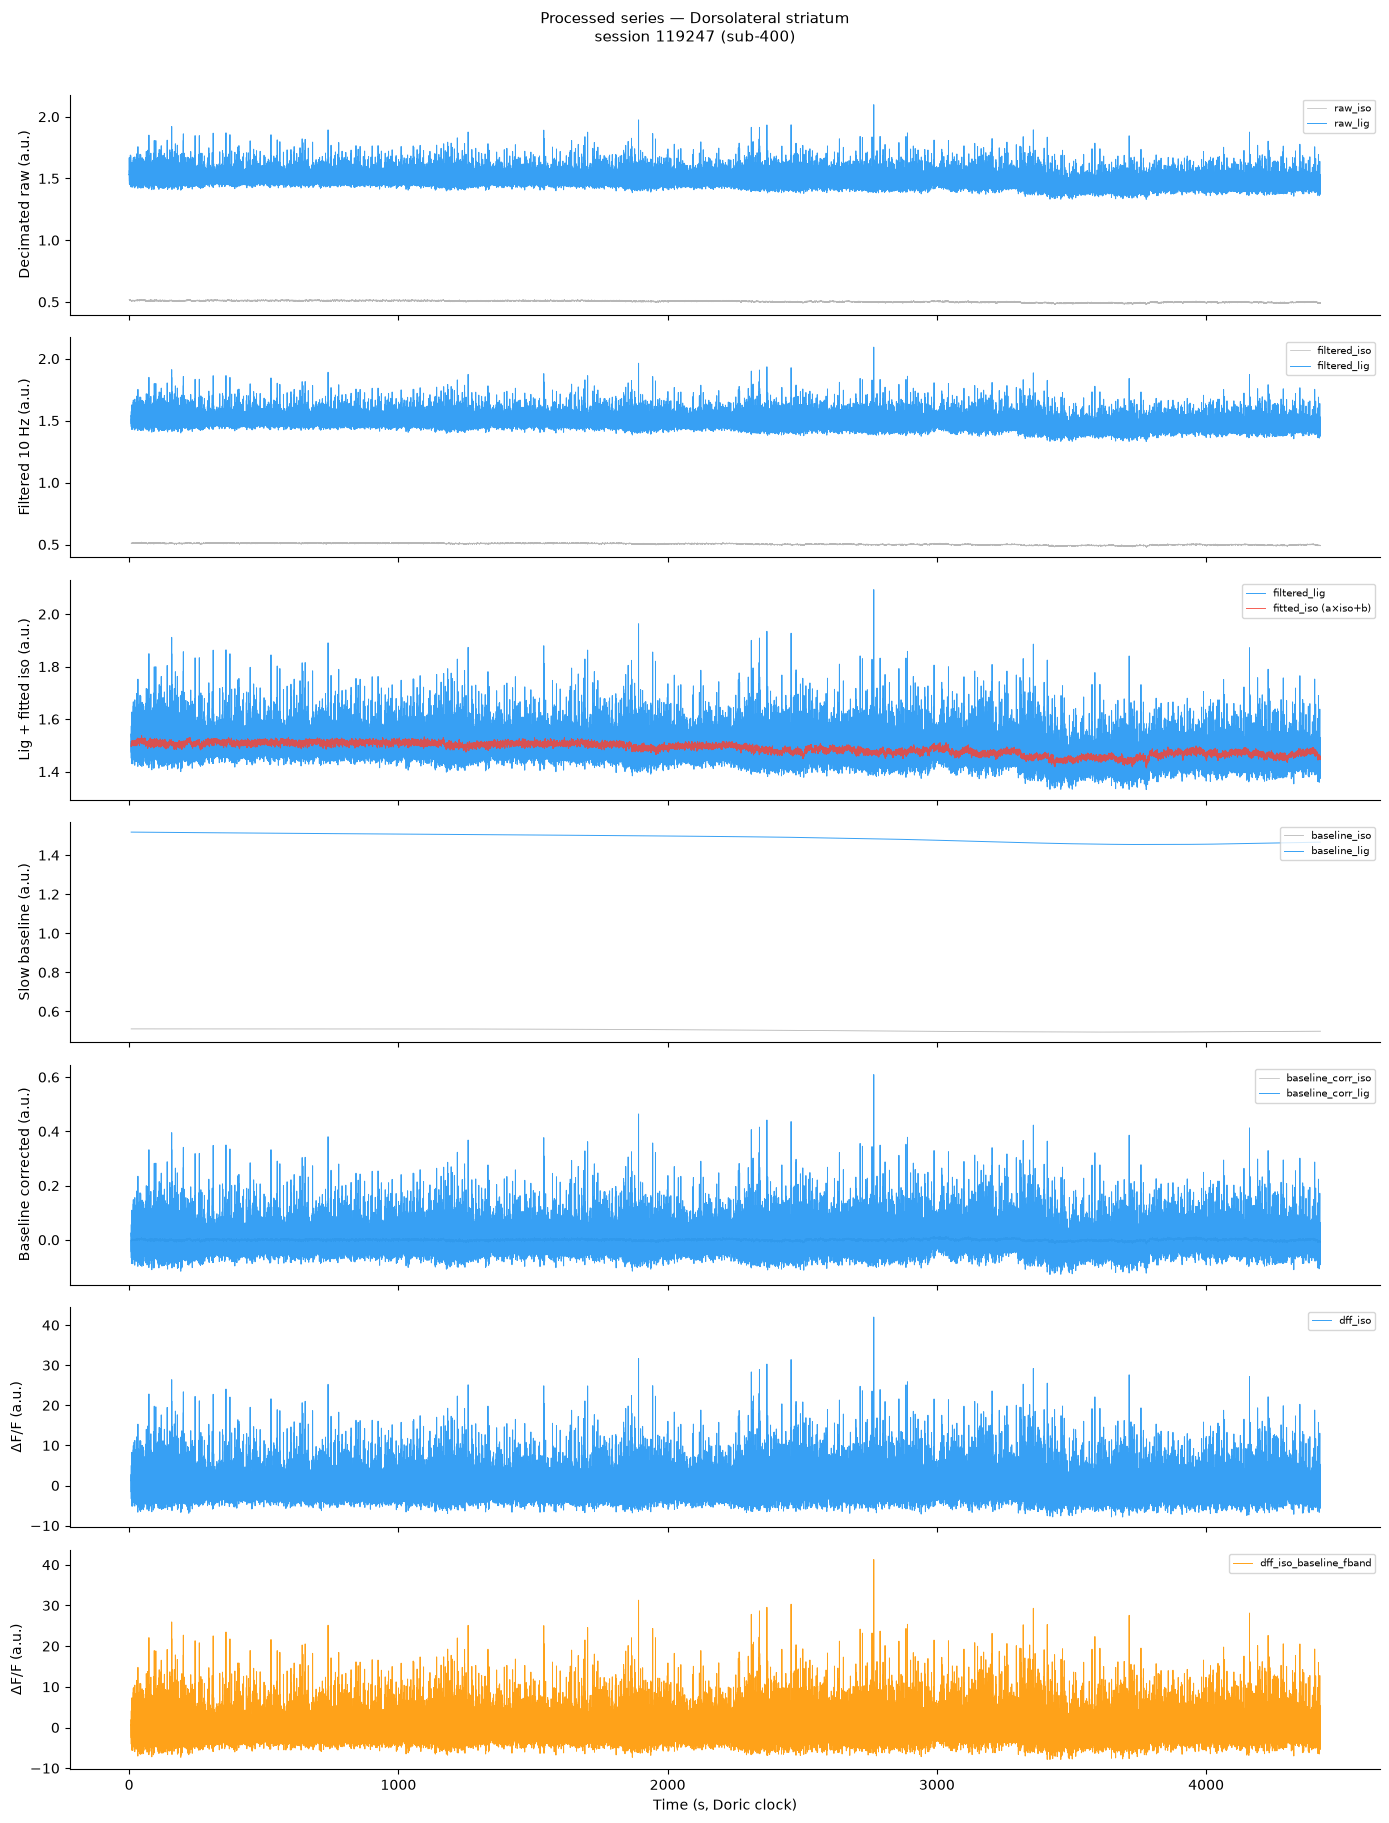

In [14]:
REGION = dec_regions[0]  # change to any available region

iso_col = region_column(dec_iso, REGION)
sig_col = region_column(dec_sig, REGION)

raw_iso  = proc_series["FiberPhotometryResponseSeriesDecimatedIsosbestic"].data[:, iso_col]
raw_lig  = proc_series["FiberPhotometryResponseSeriesDecimatedSignal"].data[:, sig_col]
filt_iso = proc_series["FiberPhotometryResponseSeriesFilteredIsosbestic"].data[:, iso_col]
filt_lig = proc_series["FiberPhotometryResponseSeriesFilteredSignal"].data[:, sig_col]
fit_iso  = proc_series["FiberPhotometryResponseSeriesFittedIsosbestic"].data[:, iso_col]
base_iso = proc_series["FiberPhotometryResponseSeriesBaselineIsosbestic"].data[:, iso_col]
base_lig = proc_series["FiberPhotometryResponseSeriesBaselineSignal"].data[:, sig_col]
bc_iso   = proc_series["FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic"].data[:, iso_col]
bc_lig   = proc_series["FiberPhotometryResponseSeriesBaselineCorrectedSignal"].data[:, sig_col]
dff      = proc_series["FiberPhotometryResponseSeriesDFF"].data[:, sig_col]
dff_fb   = proc_series["FiberPhotometryResponseSeriesDFFFreqBandCorrected"].data[:, sig_col]

color = SIGNAL_COLOR.get(REGION, "steelblue")
fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

# Row 1: decimated raw
axes[0].plot(ts, raw_iso,  color="#999",  lw=0.5, alpha=0.7, label="raw_iso",  rasterized=True)
axes[0].plot(ts, raw_lig,  color=color,   lw=0.7, alpha=0.9, label="raw_lig",  rasterized=True)
axes[0].set_ylabel("Decimated raw (a.u.)")
axes[0].legend(loc="upper right", fontsize=7)

# Row 2: filtered
axes[1].plot(ts, filt_iso, color="#999",  lw=0.5, alpha=0.7, label="filtered_iso", rasterized=True)
axes[1].plot(ts, filt_lig, color=color,   lw=0.7, alpha=0.9, label="filtered_lig", rasterized=True)
axes[1].set_ylabel("Filtered 10 Hz (a.u.)")
axes[1].legend(loc="upper right", fontsize=7)

# Row 3: filtered_lig with fitted_iso overlay
axes[2].plot(ts, filt_lig, color=color,   lw=0.7, alpha=0.9, label="filtered_lig", rasterized=True)
axes[2].plot(ts, fit_iso,  color="#F44336", lw=0.7, alpha=0.85, label="fitted_iso (a×iso+b)", rasterized=True)
axes[2].set_ylabel("Lig + fitted iso (a.u.)")
axes[2].legend(loc="upper right", fontsize=7)

# Row 4: slow baseline
axes[3].plot(ts, base_iso, color="#999",  lw=0.6, alpha=0.7, label="baseline_iso", rasterized=True)
axes[3].plot(ts, base_lig, color=color,   lw=0.7, alpha=0.9, label="baseline_lig", rasterized=True)
axes[3].set_ylabel("Slow baseline (a.u.)")
axes[3].legend(loc="upper right", fontsize=7)

# Row 5: baseline-corrected
axes[4].plot(ts, bc_iso, color="#999",  lw=0.5, alpha=0.7, label="baseline_corr_iso", rasterized=True)
axes[4].plot(ts, bc_lig, color=color,   lw=0.7, alpha=0.9, label="baseline_corr_lig", rasterized=True)
axes[4].set_ylabel("Baseline corrected (a.u.)")
axes[4].legend(loc="upper right", fontsize=7)

# Row 6: ΔF/F, linear isosbestic correction
axes[5].plot(ts, dff, color=color, lw=0.7, alpha=0.9, label="dff_iso", rasterized=True)
axes[5].set_ylabel("ΔF/F (a.u.)")
axes[5].legend(loc="upper right", fontsize=7)

# Row 7: ΔF/F, frequency-band correction
axes[6].plot(ts, dff_fb, color="#FF9800", lw=0.7, alpha=0.9, label="dff_iso_baseline_fband", rasterized=True)
axes[6].set_ylabel("ΔF/F (a.u.)")
axes[6].legend(loc="upper right", fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s, Doric clock)")
fig.suptitle(
    f"Processed series — {REGION}\n"
    f"session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 8. ΔF/F across all regions

This is the primary output: isosbestic-corrected ΔF/F (`dff_iso`) for all four regions.

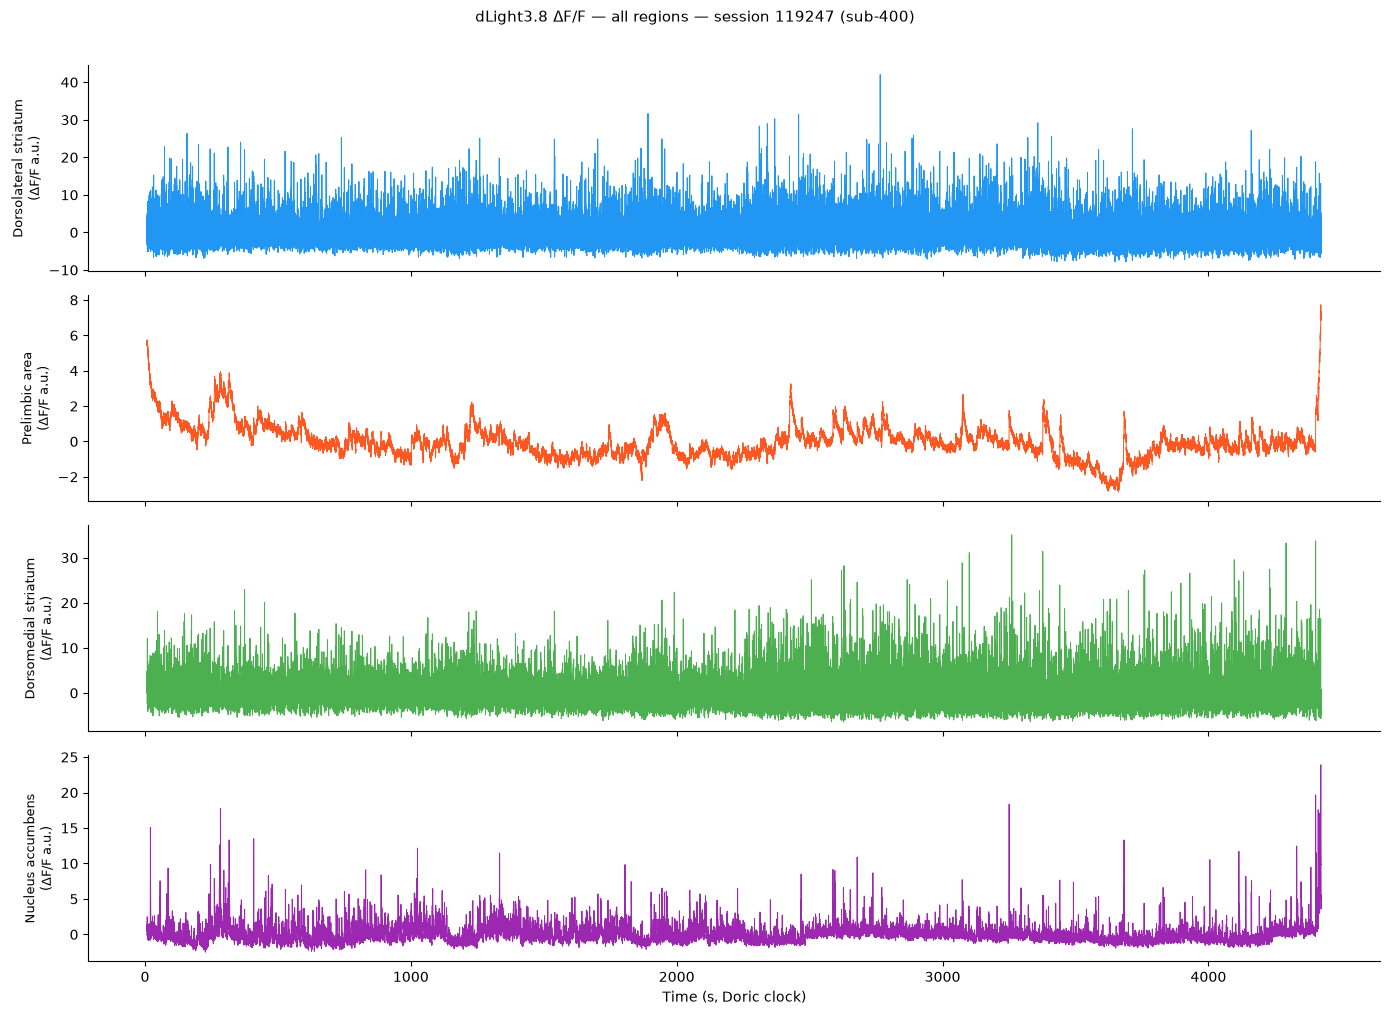

In [15]:
dff_series = proc_series["FiberPhotometryResponseSeriesDFF"]

fig, axes = plt.subplots(len(dec_regions), 1, figsize=(14, 2.5 * len(dec_regions)), sharex=True)
for ax, region in zip(np.atleast_1d(axes), dec_regions):
    ax.plot(ts, dff_series.data[:, region_column(dff_series, region)],
            color=SIGNAL_COLOR.get(region, "steelblue"), lw=0.7, rasterized=True)
    ax.set_ylabel(f"{region}\n(ΔF/F a.u.)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

np.atleast_1d(axes)[-1].set_xlabel("Time (s, Doric clock)")
fig.suptitle(
    f"dLight3.8 ΔF/F — all regions — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 9. Artifact intervals

The preprocessing workflow records the spans where a region's signal is not usable. They are
written to `nwb.intervals["fiber_photometry_artifacts_intervals"]`. Reading them from here avoids
scanning every trace for `NaN` runs. Unlike the `NaN`s themselves, the table also says *why* each
gap is there.

There are three kinds, in the `artifact_type` column:

| `artifact_type` | what it is |
|---|---|
| `dropout` | genuine loss of signal |
| `independent_range_edge` | the seam between two spans that were fitted independently |
| `pre_session_crop` | the start of the recording, discarded 5 s before the first trial |

The values are documented once in an attached **`MeaningsTable`**, not repeated on every row.
Every row references all twelve processed series through its `timeseries` column.

In [16]:
artifacts = nwb.intervals["fiber_photometry_artifacts_intervals"]
artifacts_df = artifacts.to_dataframe()

print(f"{len(artifacts_df)} artifact intervals\n")
print(artifacts_df[["start_time", "stop_time", "location", "artifact_type"]].to_string())

# The MeaningsTable documents every possible artifact_type — including ones this session
# never produced, which a per-row description column could not do.
meanings = artifacts.get_meanings_for_column("artifact_type")
print(f"\n{meanings.name}:")
for _, m in meanings.to_dataframe().iterrows():
    seen = (artifacts_df["artifact_type"] == m["value"]).sum()
    print(f"\n  {m['value']}  ({seen} row{'' if seen == 1 else 's'} in this session)")
    print(f"    {m['meaning']}")

8 artifact intervals

    start_time   stop_time               location           artifact_type
id                                                                       
0      0.08549     7.53557  Dorsolateral striatum        pre_session_crop
1      0.08549     7.53557   Dorsomedial striatum        pre_session_crop
2      0.08549     7.53557      Nucleus accumbens        pre_session_crop
3      0.08549     7.53557         Prelimbic area        pre_session_crop
4   2485.00589  2485.10051      Nucleus accumbens  independent_range_edge
5   2499.70187  2500.30445      Nucleus accumbens                 dropout
6   3067.10315  3067.50155      Nucleus accumbens                 dropout
7   3788.40635  3788.60057         Prelimbic area  independent_range_edge

artifact_type_meanings:

  dropout  (2 rows in this session)
    Loss of fiber photometry signal in this region.

  independent_range_edge  (2 rows in this session)
    Boundary between two spans of the recording that the preprocessing w

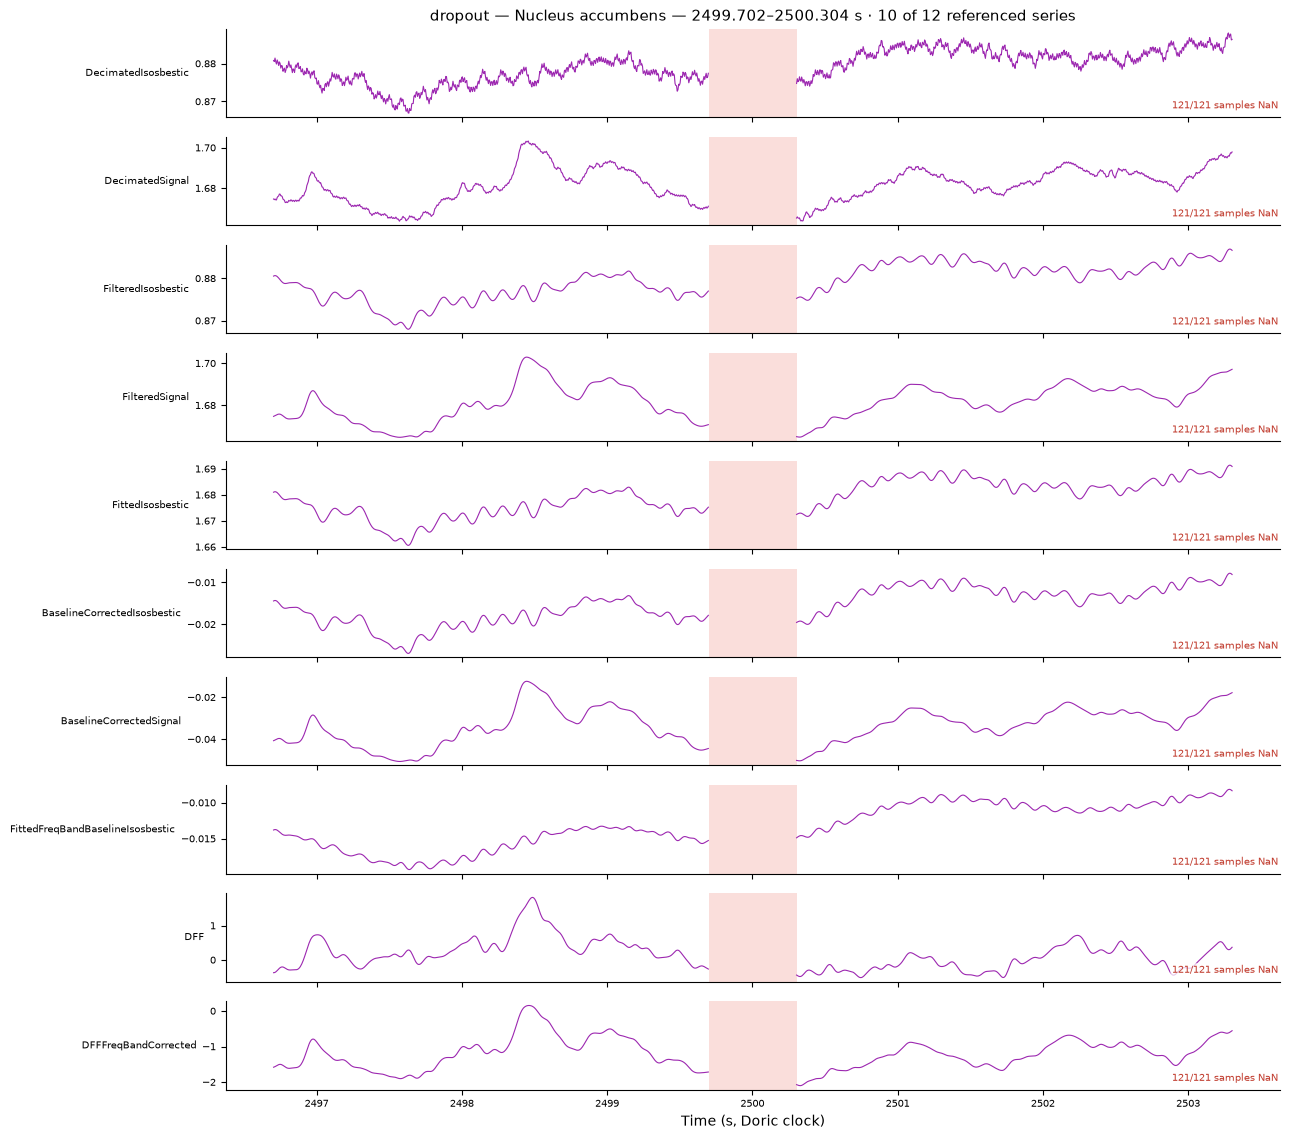

In [17]:
# Take the first dropout and follow every one of its references.
row = artifacts_df[artifacts_df["artifact_type"] == "dropout"].iloc[0]
references = {ref.timeseries.name: ref for ref in row["timeseries"]}

# Processing order, so the figure reads top-to-bottom as the pipeline runs.
# BaselineIsosbestic and BaselineSignal are referenced too, but omitted here: the baseline is
# low-pass filtered at 0.0005 Hz, so over a window of a few seconds it is a straight line and
# shows nothing about the artifact.
STAGE_ORDER = [
    "FiberPhotometryResponseSeriesDecimatedIsosbestic",
    "FiberPhotometryResponseSeriesDecimatedSignal",
    "FiberPhotometryResponseSeriesFilteredIsosbestic",
    "FiberPhotometryResponseSeriesFilteredSignal",
    "FiberPhotometryResponseSeriesFittedIsosbestic",
    "FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic",
    "FiberPhotometryResponseSeriesBaselineCorrectedSignal",
    "FiberPhotometryResponseSeriesFittedFreqBandBaselineIsosbestic",
    "FiberPhotometryResponseSeriesDFF",
    "FiberPhotometryResponseSeriesDFFFreqBandCorrected",
]
stages = [n for n in STAGE_ORDER if n in references]
PAD_S = 3.0
window = (ts >= row["start_time"] - PAD_S) & (ts <= row["stop_time"] + PAD_S)

fig, axes = plt.subplots(len(stages), 1, figsize=(13, 1.15 * len(stages)), sharex=True)
for ax, name in zip(axes, stages):
    ref = references[name]
    col = region_column(ref.timeseries, row["location"])
    values = ref.timeseries.data[:, col]

    ax.plot(ts[window], values[window], lw=0.8,
            color=SIGNAL_COLOR.get(row["location"], "steelblue"))
    ax.axvspan(row["start_time"], row["stop_time"], color="#e74c3c", alpha=0.18, lw=0)

    # The reference resolves straight to the samples inside the window; how many of them are
    # NaN is a property of the source data, not of anything the conversion did.
    snippet = values[ref.idx_start:ref.idx_start + ref.count]
    n_nan = int(np.isnan(snippet).sum())
    ax.text(0.998, 0.10, f"{n_nan}/{ref.count} samples NaN", transform=ax.transAxes,
            ha="right", fontsize=7.5, color="#c0392b" if n_nan else "#1e7a46",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))
    ax.set_ylabel(name.replace("FiberPhotometryResponseSeries", ""), fontsize=7, rotation=0,
                  ha="right", va="center")
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s, Doric clock)")
axes[0].set_title(f"{row['artifact_type']} — {row['location']} — "
                  f"{row['start_time']:.3f}–{row['stop_time']:.3f} s "
                  f"· {len(stages)} of {len(row['timeseries'])} referenced series", fontsize=11)
fig.tight_layout()
plt.show()

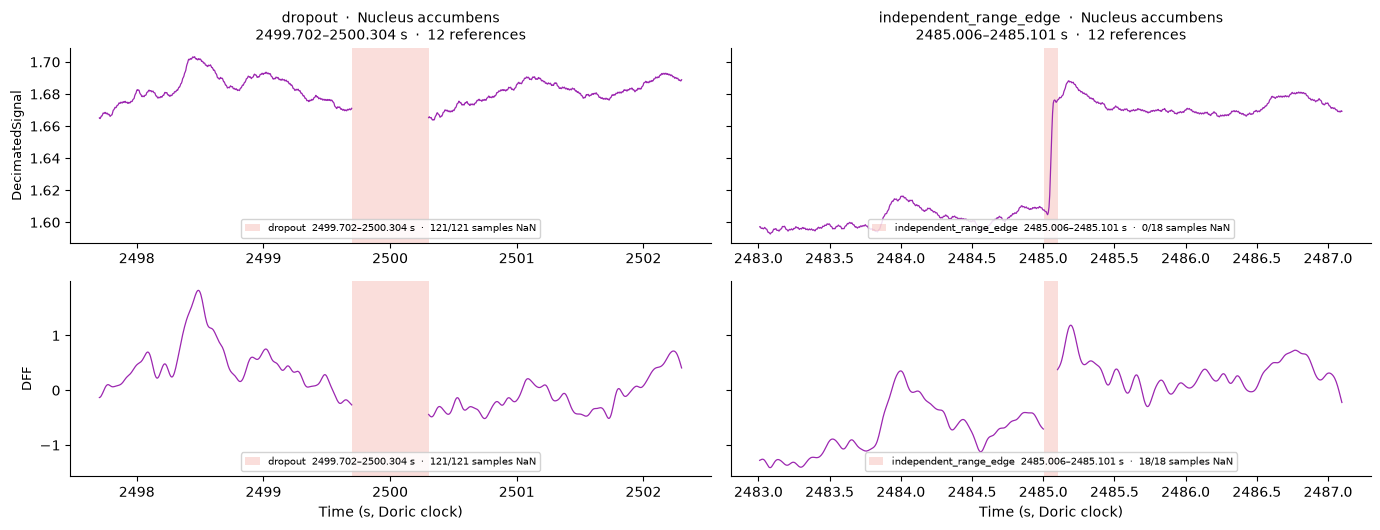

In [18]:
COMPARE = ["FiberPhotometryResponseSeriesDecimatedSignal", "FiberPhotometryResponseSeriesDFF"]
PAD_S = 2.0

types_present = [t for t in ("dropout", "independent_range_edge")
                 if (artifacts_df["artifact_type"] == t).any()]

fig, axes = plt.subplots(len(COMPARE), len(types_present),
                         figsize=(7 * len(types_present), 5.4), sharey="row", squeeze=False)

for col_i, artifact_type in enumerate(types_present):
    row = artifacts_df[artifacts_df["artifact_type"] == artifact_type].iloc[0]
    references = {ref.timeseries.name: ref for ref in row["timeseries"]}
    window = (ts >= row["start_time"] - PAD_S) & (ts <= row["stop_time"] + PAD_S)

    for row_i, name in enumerate(COMPARE):
        ax = axes[row_i][col_i]
        ref = references[name]
        values = ref.timeseries.data[:, region_column(ref.timeseries, row["location"])]

        ax.plot(ts[window], values[window], lw=0.9,
                color=SIGNAL_COLOR.get(row["location"], "steelblue"))
        span = ax.axvspan(row["start_time"], row["stop_time"], color="#e74c3c", alpha=0.18, lw=0)

        snippet = values[ref.idx_start:ref.idx_start + ref.count]
        n_nan = int(np.isnan(snippet).sum())
        ax.legend([span], [f"{row['artifact_type']}  {row['start_time']:.3f}–{row['stop_time']:.3f} s"
                           f"  ·  {n_nan}/{ref.count} samples NaN"],
                  loc="lower center", fontsize=7.5, framealpha=0.85, handlelength=1.4)
        ax.spines[["top", "right"]].set_visible(False)
        if col_i == 0:
            ax.set_ylabel(name.replace("FiberPhotometryResponseSeries", ""), fontsize=9)

    axes[0][col_i].set_title(f"{row['artifact_type']}  ·  {row['location']}\n"
                             f"{row['start_time']:.3f}–{row['stop_time']:.3f} s  ·  "
                             f"{len(row['timeseries'])} references", fontsize=10)
    axes[-1][col_i].set_xlabel("Time (s, Doric clock)")

fig.tight_layout()
plt.show()

### The `pre_session_crop` window

The largest window in every session is the start of the recording, which the preprocessing workflow
discards. Here the decimated trace shows what was cropped (grey) against what was kept. The dashed
line marks the first trial, so the gap between the end of the crop and the first trial is the
pre-trial baseline that the workflow kept.

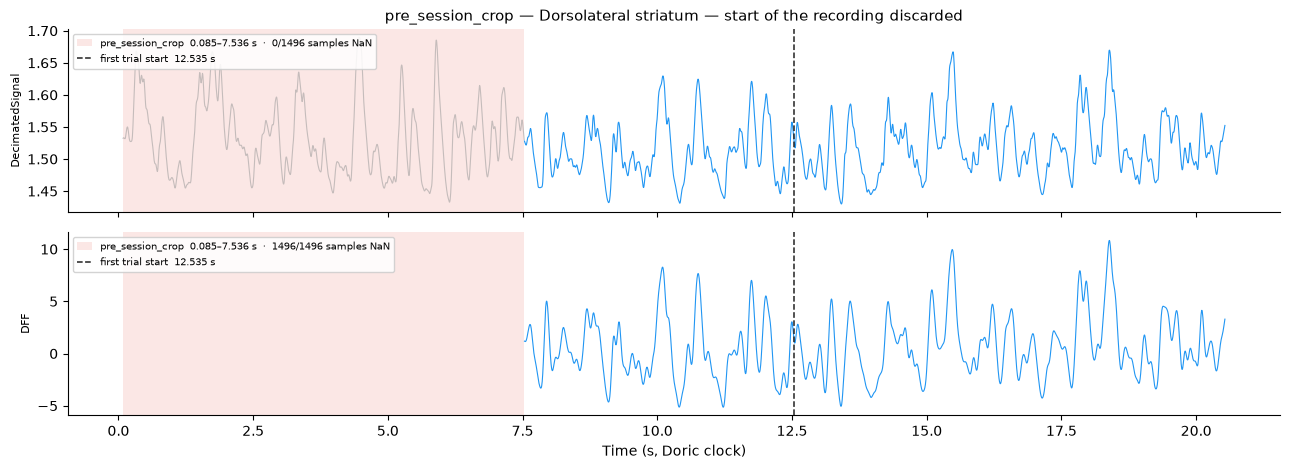

In [19]:
row = artifacts_df[artifacts_df["artifact_type"] == "pre_session_crop"].iloc[0]
references = {ref.timeseries.name: ref for ref in row["timeseries"]}
first_trial_start = float(nwb.trials["start_time"][0])

SHOW = ["FiberPhotometryResponseSeriesDecimatedSignal", "FiberPhotometryResponseSeriesDFF"]
PAD_S = 8.0

visible = ts <= first_trial_start + PAD_S
cropped = visible & (ts < row["stop_time"])
kept = visible & (ts >= row["stop_time"])

fig, axes = plt.subplots(len(SHOW), 1, figsize=(13, 2.4 * len(SHOW)), sharex=True)
for ax, name in zip(axes, SHOW):
    ref = references[name]
    values = ref.timeseries.data[:, region_column(ref.timeseries, row["location"])]

    # Grey for what falls inside the crop — present in the decimated series, absent downstream.
    ax.plot(ts[cropped], values[cropped], lw=0.8, color="#999999", alpha=0.55)
    ax.plot(ts[kept], values[kept], lw=0.8,
            color=SIGNAL_COLOR.get(row["location"], "steelblue"))

    span = ax.axvspan(row["start_time"], row["stop_time"], color="#e74c3c", alpha=0.13, lw=0)
    trial_line = ax.axvline(first_trial_start, color="#222", ls="--", lw=1.1)

    snippet = values[ref.idx_start:ref.idx_start + ref.count]
    n_nan = int(np.isnan(snippet).sum())
    ax.legend([span, trial_line],
              [f"pre_session_crop  {row['start_time']:.3f}–{row['stop_time']:.3f} s"
               f"  ·  {n_nan}/{ref.count} samples NaN",
               f"first trial start  {first_trial_start:.3f} s"],
              loc="upper left", fontsize=7.5, framealpha=0.85, handlelength=1.4)
    ax.set_ylabel(name.replace("FiberPhotometryResponseSeries", ""), fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s, Doric clock)")
axes[0].set_title(f"pre_session_crop — {row['location']} — start of the recording discarded",
                  fontsize=11)
fig.tight_layout()
plt.show()

# Part C: behavior

Behavior is recorded by a **Bpod** state machine and stored with `ndx-structured-behavior`. The
protocol here is **ToneCatDelayResp**, an auditory working-memory delayed-response task. All
timestamps are on the **Doric fiber-photometry clock** (seconds from the start of the Doric
recording), so behavioral events align directly with the fiber photometry series above.

## 10. Task metadata

The task-related general metadata is stored in a `Task` object which can be accessed as `nwb.lab_meta_data["task"]`.

The `EventTypesTable` is a column-based table to store the type of events that occur during the task (e.g. port poke from the animal), one type per row. This table can be accessed as `nwb.lab_meta_data["task"].event_types`.

Bpod reports port contacts under names that fuse the port and the edge — `Port3In`, `Port3Out`. Here the type table names only the **port**, and the edge lives in the `value` column of each occurrence row, so `Port3In` is stored as `event_name="Port3"`, `value="In"`. The raw Bpod name is always recoverable as `event_name + value`.

For this rig the three ports are: **Port1 = left**, **Port2 = center**, **Port3 = right**.

In [20]:
nwb.lab_meta_data["task"].event_types[:]

,event_name
id,
0,Port1
1,Port2
2,Port3


The `ActionTypesTable` is a column-based table to store the type of actions that occur during the task (e.g. sound output from the acquisition system), one type per row.
This table can be accessed as `nwb.lab_meta_data["task"].action_types`.

Here the actions are the machine-triggered Bpod outputs: the `BNC1` TTL line that is also recorded by the Doric system (used to synchronize the two clocks), the global timers that implement the stimulus/delay windows, `Condition1`, and `Tup` (state timer expiry).

The same name/value split applies: Bpod's `BNC1High` / `BNC1Low` become `action_name="BNC1"` with `value` `"On"` / `"Off"`, and `GlobalTimer2_End` becomes `action_name="GlobalTimer2"`, `value="End"`.

All six action types are registered in every session even when a session never fires one of them, so the registry is identical across files and can be compared directly.

In [21]:
nwb.lab_meta_data["task"].action_types[:]

,action_name
id,
0,BNC1
1,Condition1
2,GlobalTimer1
3,GlobalTimer2
4,GlobalTimer3
5,Tup


The `StateTypesTable` is a column-based table to store the type of states that occur during the task (e.g. while the animal is waiting for reward), one type per row.
This table can be accessed as `nwb.lab_meta_data["task"].state_types`.

The `GenerateTrialBit1`–`GenerateTrialBit15` states present in the raw Bpod data are **not** stored: they encode the trial number as a 15-bit TTL word for Doric synchronization rather than a behavioral state.

In [22]:
nwb.lab_meta_data["task"].state_types[:]

,state_name
id,
0,SyncBit
1,ITI
2,WaitForCenterPoke
3,StartStim
4,WaitForSync
5,StartStimulusTimer
6,Stimulus
7,StartStimLCBTimer
8,StimLCB


## 11. Behavioral data

The `TaskRecording` object stores the data for events, states, and actions that occurred during the task. The `TaskRecording` is added as acquisition which can be accessed as `nwb.acquisition["task_recording"]`.

### Events

The `EventsTable` is a column-based table to store the information about the events (e.g. poke times), one event per row. This table can be accessed as `nwb.acquisition["task_recording"].events`.

Events are **animal-triggered** port contacts. Merging against the `EventTypesTable` resolves the `event_type` foreign key to the port name; pairing that with the `value` column (`"In"` / `"Out"`) gives the original Bpod name — the row below with `event_name="Port3"` and `value="In"` is Bpod's `Port3In`.

In [23]:
pd.merge(
    nwb.acquisition["task_recording"].events[:],
    nwb.lab_meta_data["task"].event_types[:],
    left_on="event_type",
    right_on="id",
)

,timestamp,event_type,value,event_name
0,14.758558,2,In,Port3
1,14.780058,2,Out,Port3
2,20.036258,0,In,Port1
3,20.070858,0,Out,Port1
4,20.787058,0,In,Port1
...,...,...,...,...
6797,2257.521882,2,Out,Port3
6798,2257.626282,2,In,Port3
6799,2258.110382,2,Out,Port3
6800,2464.426582,1,In,Port2


### States

The `StatesTable` is a column-based table to store the information about the states (e.g. the duration while nose is in center port). This table can be accessed as `nwb.acquisition["task_recording"].states`.

Each row is one **occurrence** of a state, with `start_time` and `stop_time` in Doric-clock seconds.

In [24]:
pd.merge(
    nwb.acquisition["task_recording"].states[:],
    nwb.lab_meta_data["task"].state_types[:],
    left_on="state_type",
    right_on="id",
)

,start_time,stop_time,state_type,state_name
0,12.535158,12.536158,0,SyncBit
1,12.551158,17.551158,1,ITI
2,17.551158,239.875958,2,WaitForCenterPoke
3,239.875958,239.876058,3,StartStim
4,239.876058,239.885358,4,WaitForSync
...,...,...,...,...
1841,3983.171162,3983.172162,0,SyncBit
1842,3983.187162,3986.346162,1,ITI
1843,3986.346162,4286.346162,2,WaitForCenterPoke
1844,4286.346162,4286.346262,20,NoCenterPoke


### Actions

The `ActionsTable` stores the **machine-triggered** outputs, one per row, accessible as `nwb.acquisition["task_recording"].actions`. As with events, the `action_name` from the type table plus the `value` column reconstructs the raw Bpod name: `BNC1` + `On` is `BNC1High`, `GlobalTimer1` + `End` is `GlobalTimer1_End`, `Tup` + `Expired` is `Tup`.

In [25]:
pd.merge(
    nwb.acquisition["task_recording"].actions[:],
    nwb.lab_meta_data["task"].action_types[:],
    left_on="action_type",
    right_on="id",
)

,timestamp,action_type,value,action_name
0,12.536158,5,Expired,Tup
1,12.537158,5,Expired,Tup
2,12.538158,5,Expired,Tup
3,12.539158,5,Expired,Tup
4,12.540158,5,Expired,Tup
...,...,...,...,...
4418,3983.187162,5,Expired,Tup
4419,3986.346162,5,Expired,Tup
4420,4286.346162,5,Expired,Tup
4421,4286.346262,5,Expired,Tup


### Plot the events, actions, and states

The ``plot_events``, ``plot_actions``, and ``plot_states`` functions can consume both the raw table as well as a subset of the table as a pandas DataFrame created through slicing, e.g., via ``events[:100]`` will plot only the first 100 rows from the events table.

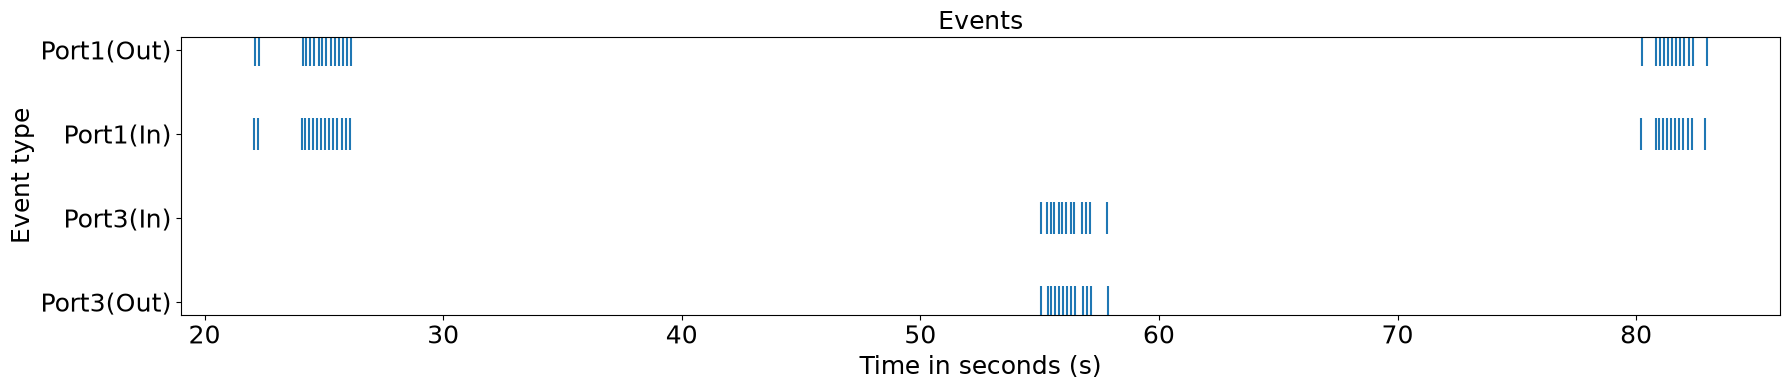

In [26]:
events = nwb.get_acquisition("task_recording").events
event_types = nwb.get_lab_meta_data("task").event_types

fig = plot_events(
    events=events[20:100],
    event_types=event_types,
    show_event_values=True,
    figsize=(18, 4),
    marker_size=500,
)
plt.title("Events", fontsize=18)
plt.tight_layout()
plt.show()

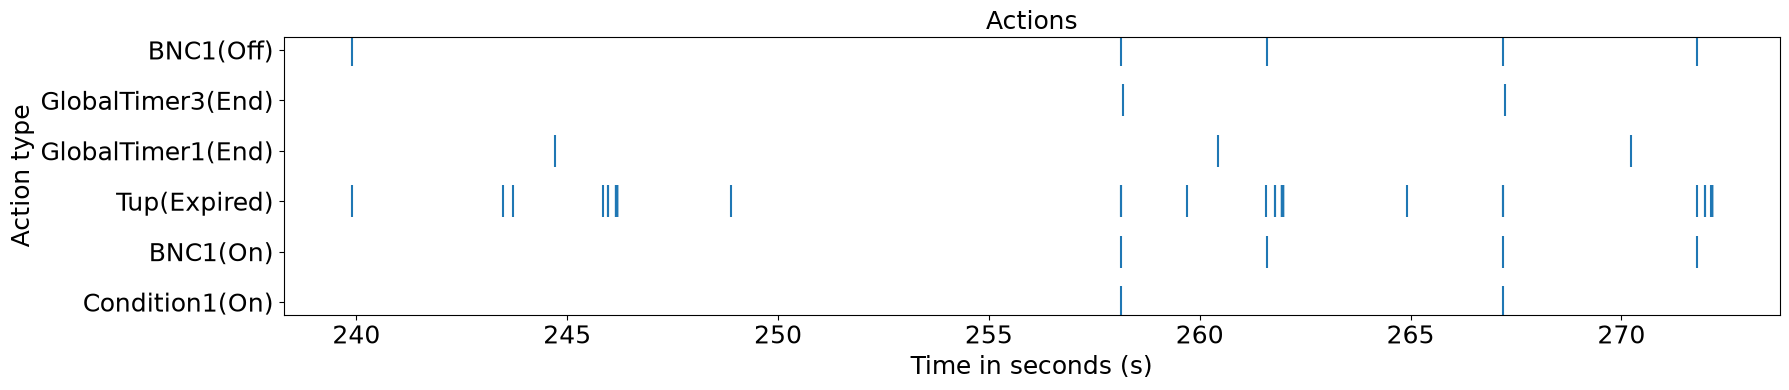

In [27]:
actions = nwb.get_acquisition("task_recording").actions
action_types = nwb.get_lab_meta_data("task").action_types

fig = plot_actions(
    actions=actions[20:100],
    action_types=action_types,
    figsize=(18, 4),
    marker_size=500,
)
plt.title("Actions", fontsize=18)
plt.tight_layout()
plt.show()

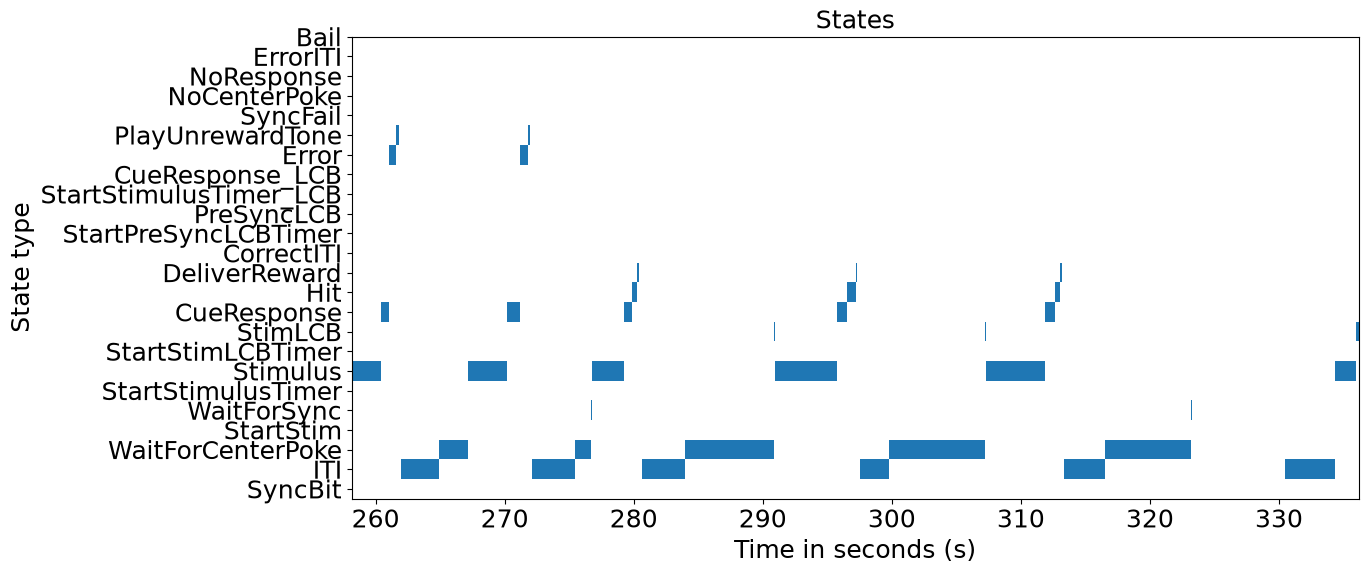

In [28]:
states = nwb.get_acquisition("task_recording").states
state_types = nwb.get_lab_meta_data("task").state_types

plot_states(
    figsize=(13, 6),
    states=states[20:100],
    state_types=state_types,
    marker_size=500,
)
plt.title("States", fontsize=18)
plt.show()

## 12. Trials

`nwb.trials` is a `TrialsTable` with one row per trial. Besides `start_time` / `stop_time` it carries three `DynamicTableRegion` columns — `states`, `events`, `actions` — each holding the row indices of that trial's entries in the tables above, plus every per-trial column from `sess_data_119247.pkl`.

In [29]:
trials = nwb.trials
trials[:].head()

,start_time,stop_time,startstage,rigid,hit,bail,reward,choice,n_tones,stim_dur,...,next_tone_info,next_correct_port,incongruent,switch,stay,next_switch,next_stay,states,events,actions
id,,,,,,,,,,,,,,,,,,,,,
0,12.535158,246.164554,7,101,True,False,20,right,1,4.819902,...,[low],left,False,False,False,False,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,246.164554,261.955138,7,101,False,False,0,right,1,2.288515,...,[low],left,False,False,True,False,True,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...","[194, 195, 196, 197, 198, 199, 200, 201, 202, ...","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3..."
2,261.955138,272.134424,7,101,False,False,0,right,1,3.026336,...,[high],right,False,False,True,False,True,"[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]","[296, 297, 298, 299, 300, 301, 302, 303, 304, ...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6..."
3,272.134424,280.609720,7,101,True,False,20,right,1,2.550231,...,[low],left,False,False,True,True,False,"[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]","[306, 307, 308, 309, 310, 311, 312, 313, 314]","[87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 9..."
4,280.609720,297.504370,7,101,True,False,20,left,1,4.853979,...,[low],left,False,True,False,False,True,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...","[315, 316, 317, 318, 319, 320, 321, 322, 323, ...","[113, 114, 115, 116, 117, 118, 119, 120, 121, ..."


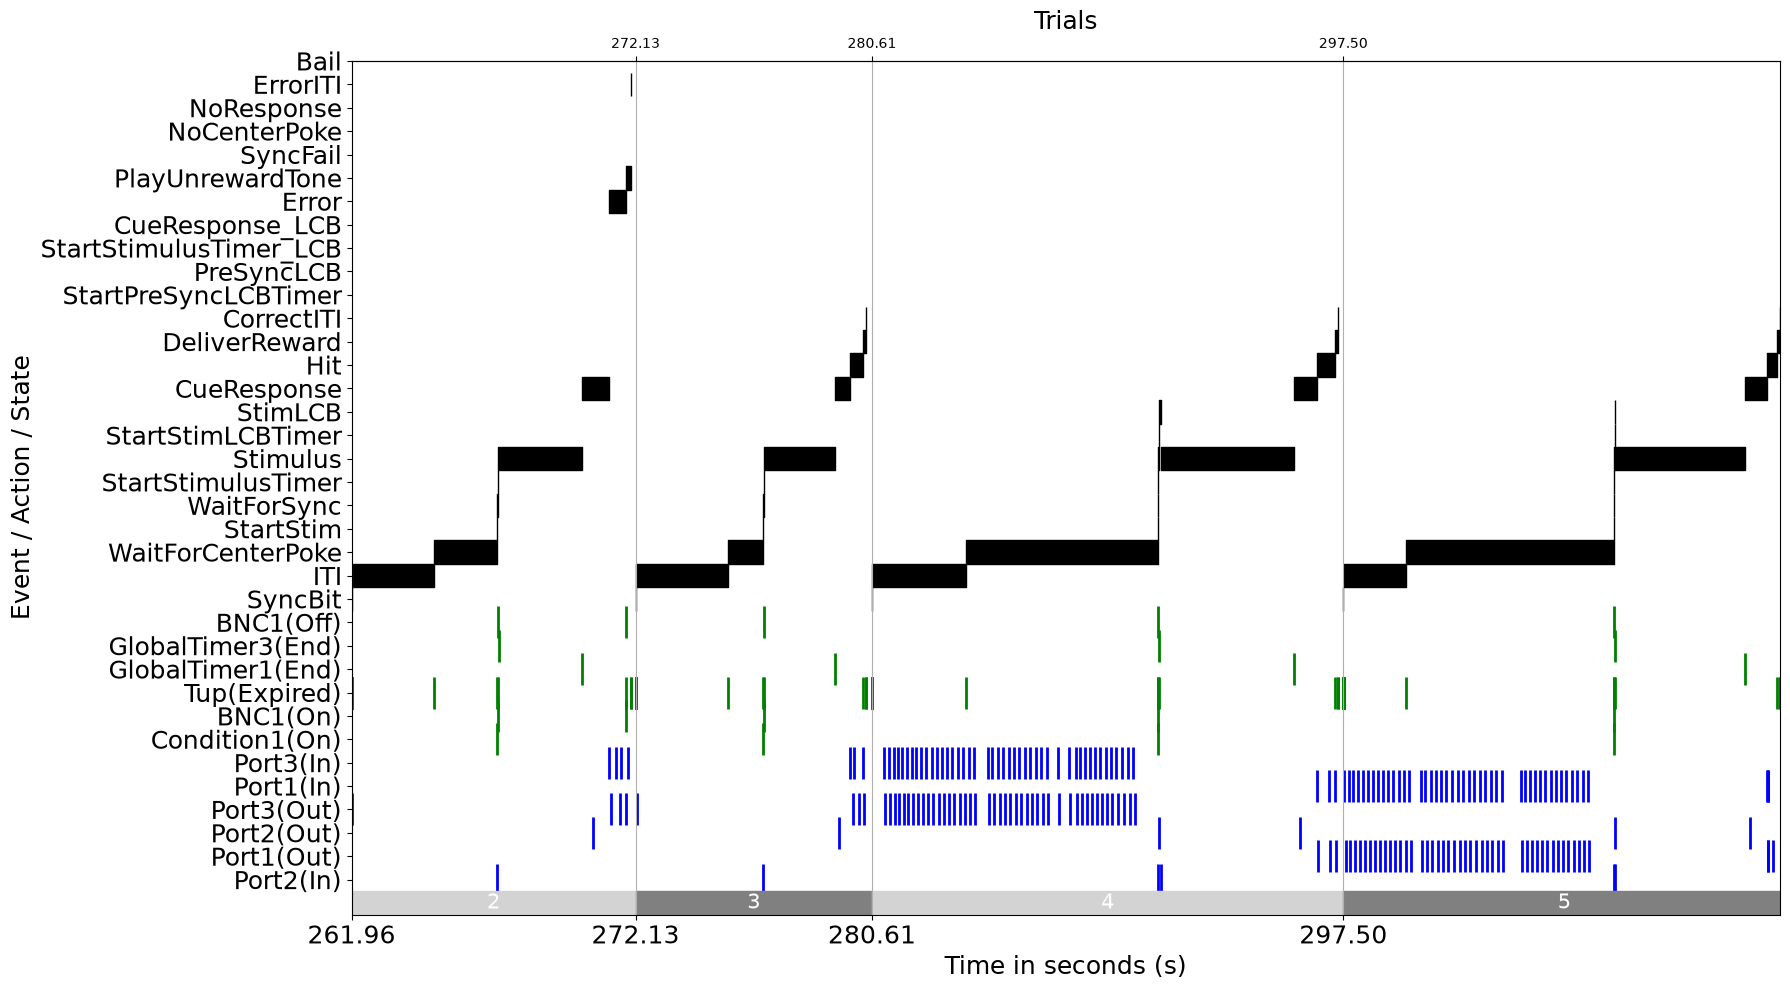

In [30]:
# Plot trials 2–5
plot_trials(
    trials=trials[2:6],
    states=states, state_types=state_types,
    actions=actions, action_types=action_types,
    events=events, event_types=event_types,
    figsize=None,
    fontsize=18,
    rectangle_height=1,
    marker_size=500)
plt.title("Trials", fontsize=18)
plt.tight_layout()
plt.show()

### What the trials table holds

Besides `start_time` / `stop_time` and the three `DynamicTableRegion` links, every per-trial column
from `sess_data_119247.pkl` is carried over, each with the description configured in
`bpod_behavior_columns.yaml`. Rather than scroll the full frame, the table below lists what is
available: storage type, how many trials have a value, an example, and what the column means.

In [31]:
trials_df = nwb.trials.to_dataframe()

# The three DynamicTableRegion columns link out to the states/events/actions tables
# rather than holding trial data themselves.
LINK_COLUMNS = ("states", "events", "actions")


def column_description(name):
    """Real description for a column.

    Ragged columns are returned as a VectorIndex, whose own description is the
    boilerplate "Index for VectorData '<name>'" — the description worth reading
    lives on the VectorData it targets.
    """
    column = nwb.trials[name]
    return column.target.description if hasattr(column, "target") else column.description


def example_value(name, values):
    if name in LINK_COLUMNS:
        return f"{len(values.iloc[0])} linked rows"
    non_null = values.dropna()
    if non_null.empty:
        return ""
    first = non_null.iloc[0]
    if isinstance(first, (list, np.ndarray)):
        # skip leading empties (e.g. prev_tone_info on the first trial)
        non_empty = [v for v in non_null if len(v)]
        if not non_empty:
            return "[]"
        first = non_empty[0]
        return "[" + ", ".join(f"{v:.4g}" if isinstance(v, (float, np.floating)) else str(v)
                               for v in list(first)[:2]) + "]"
    return f"{first:.4g}" if isinstance(first, (float, np.floating)) else str(first)


def storage_kind(name, values):
    if name in LINK_COLUMNS:
        return "link"
    non_null = values.dropna()
    if non_null.empty:
        return "empty"
    first = non_null.iloc[0]
    if isinstance(first, (list, np.ndarray)):
        return "ragged"
    return type(first).__name__.replace("64", "").replace("_", "")


columns = pd.DataFrame([
    dict(column=name,
         type=storage_kind(name, trials_df[name]),
         filled=f"{trials_df[name].notna().sum()}/{len(trials_df)}",
         example=example_value(name, trials_df[name]),
         description=column_description(name))
    for name in nwb.trials.colnames
])

pd.set_option("display.max_rows", None, "display.max_colwidth", 60, "display.width", 200)
columns

,column,type,filled,example,description
0,start_time,float,165/165,12.54,"Start time of epoch, in seconds"
1,stop_time,float,165/165,246.2,"Stop time of epoch, in seconds"
2,startstage,int,165/165,7,Training stage number at session start.
3,rigid,int,165/165,101,Rig ID where the session was run.
4,hit,bool,165/165,True,True if the animal made a valid response within the resp...
5,bail,bool,165/165,False,True if the animal withdrew from center port before the ...
6,reward,int,165/165,20,Reward volume delivered (µL); 0 if unrewarded.
7,choice,str,165/165,right,"Side the animal chose: 'left', 'right', or 'none'."
8,n_tones,int,165/165,1,Number of tones presented during the stimulus window.
9,stim_dur,float,165/165,4.82,Stimulus window duration (seconds).


## 13. Trial-aligned fiber photometry

Behavior and fiber photometry share the Doric clock, so a time from the trials table indexes
directly into any response series with no conversion. This section cuts a window around a task
event in every trial and stacks the windows.

### Raw signal around the response cue

Here **t = 0 is the response cue**: the `response_cue_time` column of the trials table, when the
sound signalling the end of the delay plays. The figure uses the raw ~6 kHz acquisition series,
with no processing. From top to bottom:

- the mean 490 nm signal across trials
- the mean isosbestic control across trials
- every trial as one row, in session order, shown as the change from that trial's own pre-cue
  baseline, so the color scale starts at 0 (no change)

The raw series is chunked in small blocks, so each trial's window is a separate small read. Over
HTTP this takes a minute or two for ~140 trials.

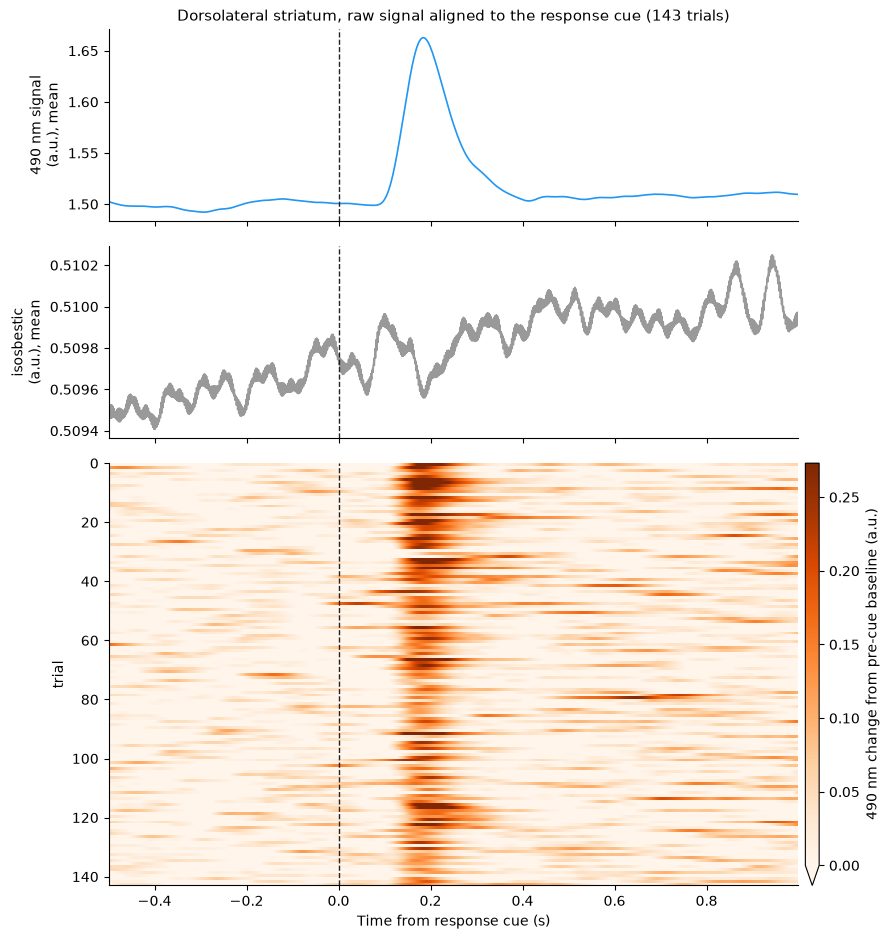

In [32]:
REGION = "Dorsolateral striatum"
PRE_S, POST_S = 0.5, 1.0

# The raw series stores ~26 M explicit timestamps. Rather than stream all of them, take the rate
# and first timestamp from the start and convert each event time to a sample index.
raw_t0 = float(sig_series.timestamps[0])
raw_rate = 1 / np.median(np.diff(sig_series.timestamps[:1000]))
n_pre, n_post = int(PRE_S * raw_rate), int(POST_S * raw_rate)
raw_lags = np.arange(-n_pre, n_post) / raw_rate

cue_times = trials_df["response_cue_time"].dropna().to_numpy()
centres = np.round((cue_times - raw_t0) * raw_rate).astype(int)

sig_col = region_column(sig_series, REGION)
iso_col = region_column(iso_series, REGION)
sig_snips = np.stack([sig_series.data[c - n_pre:c + n_post, sig_col] for c in centres])
iso_snips = np.stack([iso_series.data[c - n_pre:c + n_post, iso_col] for c in centres])

fig, axes = plt.subplots(3, 1, figsize=(9, 9.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 1, 2.2]))

axes[0].plot(raw_lags, sig_snips.mean(axis=0), color=SIGNAL_COLOR[REGION], lw=1.2)
axes[0].set_ylabel(f"490 nm signal\n({sig_series.unit}), mean")
axes[0].set_title(f"{REGION}, raw signal aligned to the response cue "
                  f"({len(cue_times)} trials)", fontsize=11)

axes[1].plot(raw_lags, iso_snips.mean(axis=0), color="#999999", lw=1.2)
axes[1].set_ylabel(f"isosbestic\n({iso_series.unit}), mean")

# Change from each trial's own pre-cue baseline, so 0 means "no change" and is the lightest color.
# Dips below baseline are clipped to 0 (the arrow at the bottom of the colorbar).
sig_change = sig_snips - sig_snips[:, raw_lags < 0].mean(axis=1, keepdims=True)
image = axes[2].imshow(sig_change, aspect="auto", cmap="Oranges", interpolation="nearest",
                       extent=[raw_lags[0], raw_lags[-1], len(cue_times), 0],
                       vmin=0, vmax=np.percentile(sig_change, 99.5))
axes[2].set_ylabel("trial")
# Inset colorbar, so the heatmap keeps the same width (and x-scale) as the panels above
fig.colorbar(image, cax=axes[2].inset_axes([1.01, 0, 0.02, 1]), extend="min",
             label=f"490 nm change from pre-cue baseline ({sig_series.unit})")

for ax in axes:
    ax.axvline(0, color="#222", ls="--", lw=1)
    ax.spines[["top", "right"]].set_visible(False)
axes[-1].set_xlabel("Time from response cue (s)")
fig.tight_layout()
plt.show()

The 490 nm signal rises about 0.1 s after the cue and peaks at about 0.18 s, in nearly every trial.
The isosbestic control does not change, so this is a dopamine response to the cue rather than a
motion artifact.

### Mean ΔF/F around three task events

The same idea for `DFF`, in all four regions. Each row aligns to one event from the trials table:

| Row | Event | Trials table column |
|---|---|---|
| Tone onset | Start of the stimulus tone (one per trial in this session) | `abs_tone_start_times` |
| Response cue | End of the delay, when the rat may respond | `response_cue_time` |
| Reward | Reward delivery, rewarded trials only | `reward_time` |

The dashed line is the event. Trials that overlap an artifact interval have `NaN` samples there, so
the averages use `nanmean`.

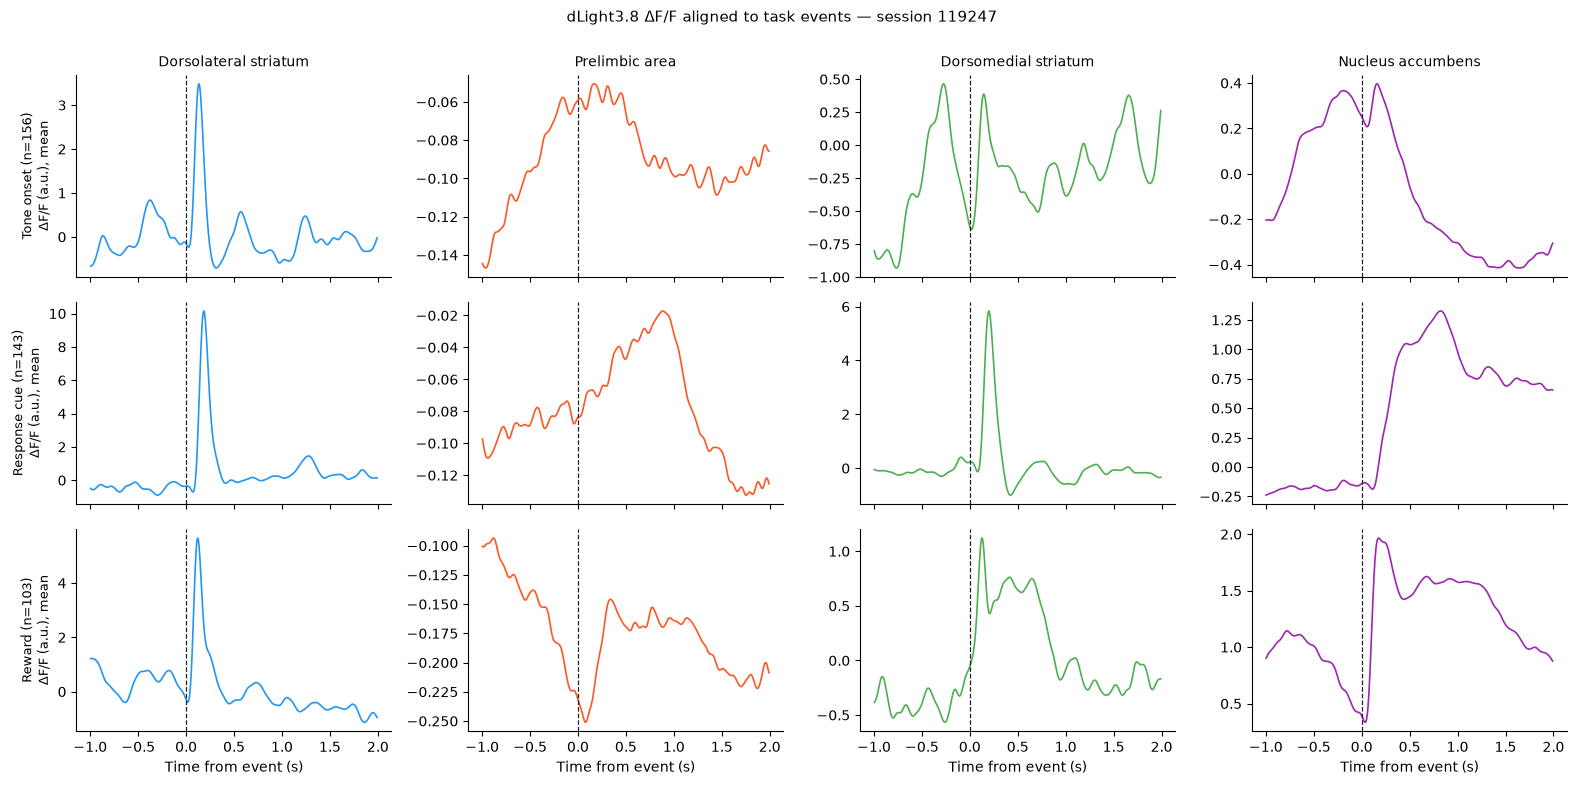

In [33]:
dff_data = dff_series.data[:]  # (n_samples, n_regions), one read for all regions
PRE_S, POST_S = 1.0, 2.0
n_pre, n_post = int(PRE_S * dff_series.rate), int(POST_S * dff_series.rate)
lags = np.arange(-n_pre, n_post) / dff_series.rate

rewarded = trials_df[trials_df["rewarded"] == True]
EVENTS = {
    "Tone onset": np.concatenate([np.atleast_1d(v) for v in trials_df["abs_tone_start_times"] if len(v)]),
    "Response cue": trials_df["response_cue_time"].dropna().to_numpy(),
    "Reward": rewarded["reward_time"].dropna().to_numpy(),
}

fig, axes = plt.subplots(len(EVENTS), len(dec_regions), figsize=(4 * len(dec_regions), 2.6 * len(EVENTS)),
                         sharex=True, squeeze=False)
for row, (label, times) in enumerate(EVENTS.items()):
    centres = np.searchsorted(ts, times)
    centres = centres[(centres >= n_pre) & (centres + n_post <= len(ts))]
    for ax, region in zip(axes[row], dec_regions):
        col = region_column(dff_series, region)
        mean = np.nanmean(np.stack([dff_data[c - n_pre:c + n_post, col] for c in centres]), axis=0)
        ax.plot(lags, mean, color=SIGNAL_COLOR.get(region, "steelblue"), lw=1.2)
        ax.axvline(0, color="#222", ls="--", lw=0.9)
        ax.spines[["top", "right"]].set_visible(False)
        if row == 0:
            ax.set_title(region, fontsize=10)
    axes[row][0].set_ylabel(f"{label} (n={len(centres)})\nΔF/F (a.u.), mean", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("Time from event (s)")
fig.suptitle(f"dLight3.8 ΔF/F aligned to task events — session {nwb.session_id}", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

## 14. State transition matrix

Here we compute the state transition matrix for all states throughout the experiment. However, simply by subsetting the StatesTable we can also create the transition matrix for any subset of state transitions, e.g., by selecting only the states from a subset of trials based on the TrialsTable.

In [34]:
# Compute the transition count and probability matrix
state_transition_count_df, state_transition_probability_df = compute_state_transition_matrix(
    states=states, state_types=state_types
)

display(state_transition_count_df)
# display(state_transition_probability_df)

to,SyncBit,ITI,WaitForCenterPoke,StartStim,WaitForSync,StartStimulusTimer,Stimulus,StartStimLCBTimer,StimLCB,CueResponse,...,PreSyncLCB,StartStimulusTimer_LCB,CueResponse_LCB,Error,PlayUnrewardTone,SyncFail,NoCenterPoke,NoResponse,ErrorITI,Bail
from,,,,,,,,,,,,,,,,,,,,,
SyncBit,0,165,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ITI,0,0,165,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WaitForCenterPoke,0,0,0,159,0,0,0,0,0,0,...,0,0,0,0,0,0,6,0,0,0
StartStim,0,0,0,0,159,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WaitForSync,0,0,0,0,0,158,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
StartStimulusTimer,0,0,0,0,0,0,158,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Stimulus,0,0,0,0,0,0,0,44,0,142,...,0,0,0,0,0,0,0,0,0,0
StartStimLCBTimer,0,0,0,0,0,0,0,0,44,0,...,0,0,0,0,0,0,0,0,0,0
StimLCB,0,0,0,0,0,0,28,0,0,0,...,0,0,1,0,0,0,0,0,0,15


### State transition graph

The transition probabilities above are easier to read as a directed graph. Node color marks the role of each state in the trial, edge width and opacity scale with transition probability, and only transitions with `p >= 0.25` are labelled so the dominant path stays readable.

The three timer-arming states (`StartStim`, `StartStimulusTimer`, `StartStimLCBTimer`) are **bridged out** rather than deleted — see the comment in the cell below for why deleting them outright inverts the meaning of the graph.

The main loop then reads clockwise from the green trial-start node:

`SyncBit -> ITI -> WaitForCenterPoke -> WaitForSync -> Stimulus -> CueResponse -> Hit -> DeliverReward -> CorrectITI` and back to `SyncBit`.

The branches off it are the failure modes: `NoCenterPoke` (4% of trials, the rat never pokes), `Bail` (withdrawal during the stimulus, via `StimLCB`), and the error path `Error -> PlayUnrewardTone -> ErrorITI`. All of them rejoin at the trial start.

Bridged out : ['StartStim', 'StartStimLCBTimer', 'StartStimulusTimer']
Remaining   : ['Bail', 'CorrectITI', 'CueResponse', 'CueResponse_LCB', 'DeliverReward', 'Error', 'ErrorITI', 'Hit', 'ITI', 'NoCenterPoke', 'PlayUnrewardTone', 'StimLCB', 'Stimulus', 'SyncBit', 'SyncFail', 'WaitForCenterPoke', 'WaitForSync']


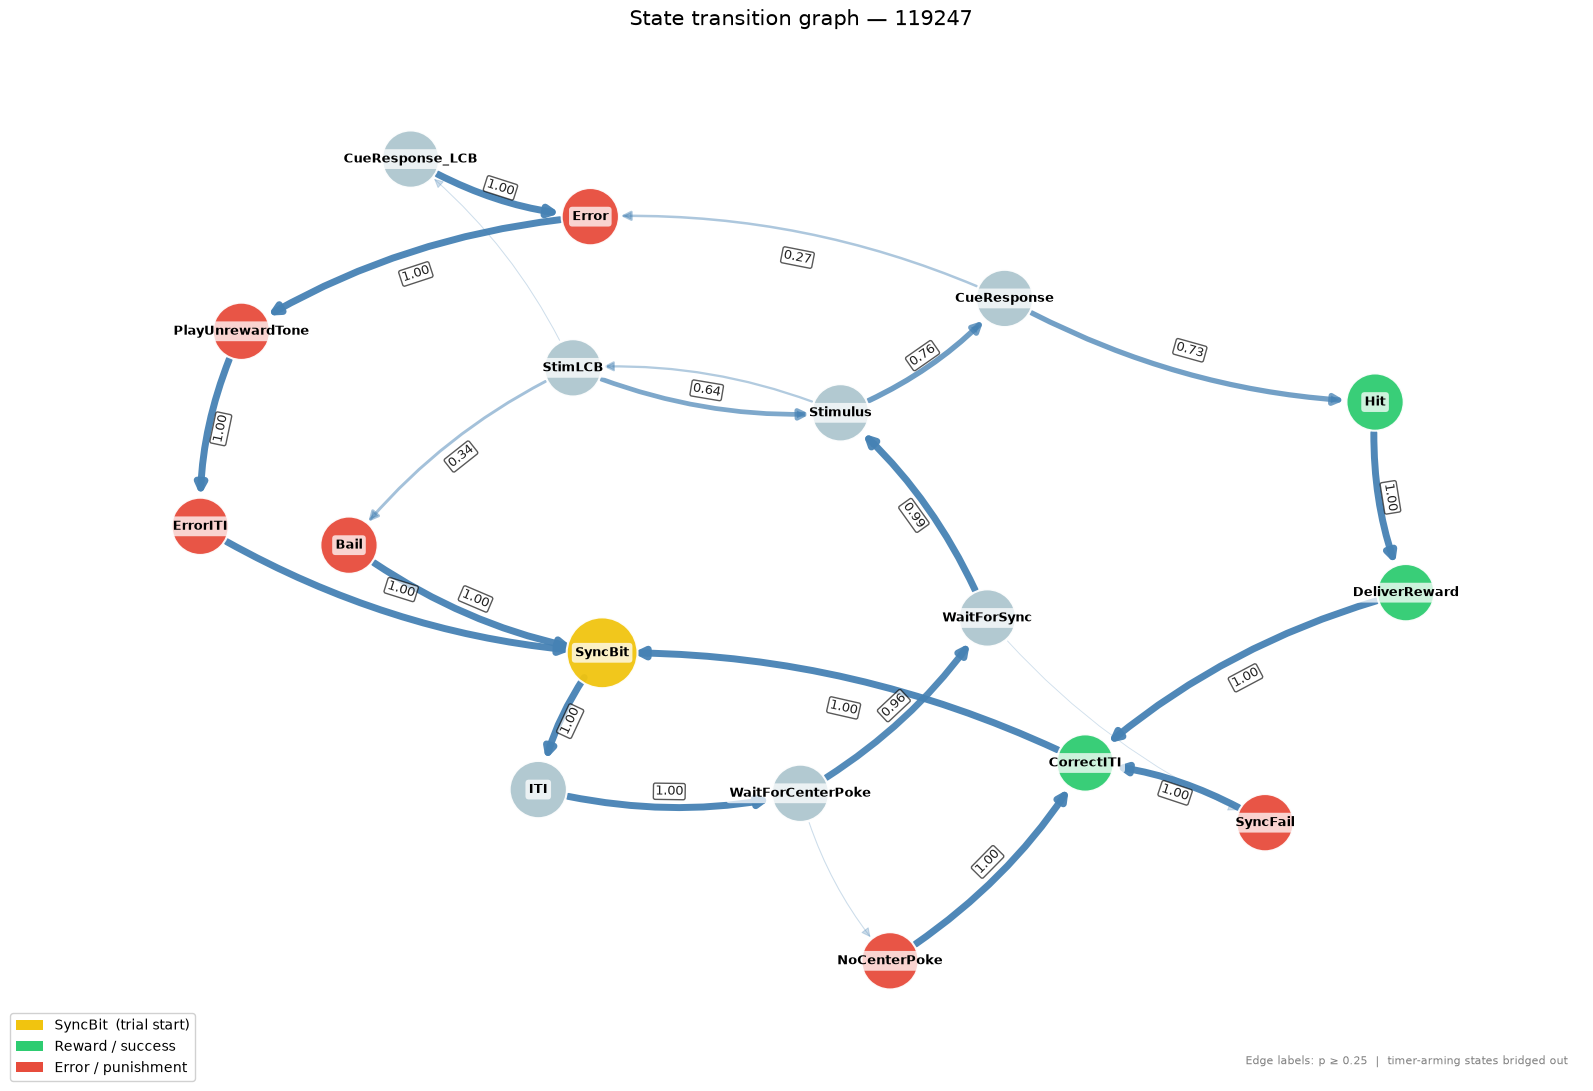

In [35]:
prob_df = state_transition_probability_df

# ── Semantic roles for this protocol ──────────────────────────────────────────
# Bpod state names are CamelCase, so match on the exact names rather than on
# lowercase keywords — "PlayUnrewardTone" contains "reward" but is an error state.
TRIAL_START   = "SyncBit"   # first state of all 165 trials
REWARD_STATES = {"Hit", "DeliverReward", "CorrectITI"}
ERROR_STATES  = {"Error", "ErrorITI", "PlayUnrewardTone", "NoResponse",
                 "NoCenterPoke", "SyncFail", "Bail"}

# ── Build base active matrix (drop all-zero rows/cols) ────────────────────────
mask   = (prob_df != 0).any(axis=1)
active = prob_df.loc[mask, prob_df.columns[(prob_df != 0).any(axis=0)]]

# ── Splice out the timer-arming states ────────────────────────────────────────
# StartStim, StartStimulusTimer and StartStimLCBTimer each last a single Bpod tick
# (1e-4 s) and exist only to arm a global timer — plumbing, not behavior.
#
# They are *bridged*, not merely deleted. Deleting the rows and columns outright
# would remove the WaitForCenterPoke -> StartStim -> WaitForSync path taken on 96%
# of trials and leave only the 6-trial NoCenterPoke failure edge, making the graph
# read as though the rat never poked. Absorbing them preserves path probability:
# for A -> D -> B with D dropped, the bridged edge A -> B carries p(A->D) * p(D->B).
labels = sorted(set(active.index) | set(active.columns))
P = active.reindex(index=labels, columns=labels).fillna(0.0)

drop_states = [s for s in labels if s.startswith("Start")]
keep_states = [s for s in labels if s not in drop_states]

if drop_states:
    P_kk = P.loc[keep_states, keep_states].to_numpy(float)
    P_kd = P.loc[keep_states, drop_states].to_numpy(float)
    P_dd = P.loc[drop_states, drop_states].to_numpy(float)
    P_dk = P.loc[drop_states, keep_states].to_numpy(float)
    # (I - P_dd)^-1 sums over paths of any length through the dropped states
    bridge = np.linalg.solve(np.eye(len(drop_states)) - P_dd, P_dk)
    filtered = pd.DataFrame(P_kk + P_kd @ bridge, index=keep_states, columns=keep_states)
else:
    filtered = P

filtered = filtered.loc[(filtered > 0).any(axis=1), filtered.columns[(filtered > 0).any(axis=0)]]

print(f"Bridged out : {drop_states}")
print(f"Remaining   : {filtered.index.tolist()}")

# ── Build directed graph ──────────────────────────────────────────────────────
G = nx.DiGraph()
for src in filtered.index:
    for dst in filtered.columns:
        prob = filtered.loc[src, dst]
        if prob > 0:
            G.add_edge(src, dst, weight=prob)

# ── Node colors by semantic role ─────────────────────────────────────────────
def node_color(name):
    if name == TRIAL_START:       return "#f1c40f"  # gold
    if name in REWARD_STATES:     return "#2ecc71"  # green
    if name in ERROR_STATES:      return "#e74c3c"  # red
    return "#aec6cf"                                # blue-grey

node_colors = [node_color(n) for n in G.nodes()]
node_sizes  = [2600 if n == TRIAL_START else 1700 for n in G.nodes()]

# ── Layout ────────────────────────────────────────────────────────────────────
try:
    pos = nx.kamada_kawai_layout(G, weight=None)
except Exception:
    pos = nx.spring_layout(G, seed=42, k=2.0)

# kamada_kawai can place two nodes almost on top of each other. Nudge apart any pair
# closer than MIN_SEP — only the topology carries meaning here, not the coordinates.
MIN_SEP = 0.20
nodes = list(G.nodes())
for _ in range(50):
    moved = False
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            a, b = np.asarray(pos[nodes[i]]), np.asarray(pos[nodes[j]])
            dist = np.linalg.norm(a - b)
            if dist < MIN_SEP:
                push = (a - b) / max(dist, 1e-9) * (MIN_SEP - dist) / 2
                pos[nodes[i]], pos[nodes[j]] = a + push, b - push
                moved = True
    if not moved:
        break

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))

# 1. Nodes first
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    edgecolors="white", linewidths=1.5, alpha=0.95,
)

# 2. Edges — width and alpha scale with probability
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
max_w = max(all_weights) if all_weights else 1.0

for src, dst, data in G.edges(data=True):
    w = data["weight"]
    nx.draw_networkx_edges(
        G, pos, edgelist=[(src, dst)], ax=ax,
        width=0.6 + 4.4 * w / max_w,
        alpha=0.25 + 0.70 * w / max_w,
        edge_color="steelblue",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        connectionstyle="arc3,rad=0.12",
        min_source_margin=22,
        min_target_margin=22,
    )

# 3. Edge labels (dominant transitions only)
LABEL_THRESHOLD = 0.25
edge_labels = {
    (src, dst): f"{data['weight']:.2f}"
    for src, dst, data in G.edges(data=True)
    if data["weight"] >= LABEL_THRESHOLD
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_size=9, font_color="#222222",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.65),
)

# 4. Node labels LAST — drawn on top of everything with an opaque white backing
#    so edges passing through a node center cannot bleed into the text.
for node, (x, y) in pos.items():
    ax.text(
        x, y, node,
        ha="center", va="center",
        fontsize=9.5, fontweight="bold", color="black",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor="#f1c40f", label=f"{TRIAL_START}  (trial start)"),
    Patch(facecolor="#2ecc71", label="Reward / success"),
    Patch(facecolor="#e74c3c", label="Error / punishment"),
    #Patch(facecolor="#aec6cf", label="Normal flow"),
]
ax.legend(handles=legend_elements, loc="lower left", bbox_to_anchor=(-0.01, -0.01),
          fontsize=10, framealpha=0.9)
ax.text(
    0.99, 0.01,
    f"Edge labels: p ≥ {LABEL_THRESHOLD}  |  timer-arming states bridged out",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray",
)
ax.set_title(f"State transition graph — {nwb.session_id}", fontsize=15, pad=12)
ax.margins(0.13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 15. Closing the stream

Nothing is written. Closing releases the HTTP session and the local chunk cache.

In [36]:
io.close()
file.close()